# Exploratory Data Analysis (EDA) - Assignment 1

**Student Name:** Elior Nassi  
**Student ID:** 314806704  
**Course:** Introduction to Data Science  
**Lecturer:** Dr. Ori Itai  
**Tutor:** Hanit Ohayon Hadad  
**Submission Date:** 2.8.2026  
**Submission Format:** Individual  

---

## 1. Project Introduction

This assignment presents an Exploratory Data Analysis (EDA) of a global maritime anchorage dataset containing more than 165,000 identified vessel anchorage locations worldwide.

The purpose of this analysis is not only to describe the dataset statistically but also to examine it as the outcome of a real-world data collection process. Accordingly, the dataset is analyzed as a complete data system by investigating its internal structure, the assumptions underlying its construction, and the limitations and potential biases that may influence future analyses.

The internal structure of the dataset includes geographical coordinates, country identifiers, anchorage labels, shoreline distance measurements, vessel drift radius estimates, docking indicators, and metadata describing the origin of each anchorage label. These variables enable both numerical and categorical analyses while providing geographical context for each observation.

Several implicit assumptions are embedded in the dataset. For example, each record is assumed to represent a valid and unique anchorage location, geographical coordinates are assumed to be sufficiently accurate, and the reported measurements are assumed to have been produced using consistent methodologies across different regions and data sources.

The dataset also contains inherent limitations that must be considered during the analysis. It represents static anchorage locations rather than vessel movements over time, and therefore cannot be used to study navigation patterns or traffic dynamics. Furthermore, since anchorage names originate from multiple external sources and manual corrections, differences in naming conventions, geographical coverage, and regional completeness may introduce inconsistencies and potential biases.

Throughout this report, the dataset will be evaluated by examining its quality, completeness, distributions, missing values, duplicate records, outliers, relationships between variables, and overall suitability for future statistical or engineering applications.

## 2. Dataset Selection

- **Dataset source:** The dataset was downloaded from Kaggle as a CSV file (`ocean_data.csv`): https://www.kaggle.com/datasets/anarjinary/global-anchorages

- **Original data source:** According to the dataset documentation, the original anchorage data is primarily based on Global Fishing Watch and additional maritime reference databases. The Kaggle dataset was published by A. Narjinary.

- **Download date:** July 2026.

- **Dataset description:** The dataset contains more than 165,000 identified maritime anchorage locations worldwide. Each record represents a known anchorage location and includes geographical coordinates, country identifiers, anchorage labels, shoreline distance, vessel drift radius, docking information, and metadata describing the source of the anchorage name.

- **Original collection purpose:** Based on the available documentation, the dataset was created to identify and describe global vessel anchorage locations rather than to record vessel movements or maritime events over time.

- **Domain context:** The dataset is suitable for exploratory analysis of global maritime infrastructure, spatial distributions, geographical patterns, and anchorage characteristics. It combines numerical, categorical, Boolean, and geospatial variables, making it appropriate for a comprehensive Exploratory Data Analysis (EDA).

- **Known limitations:** The available documentation does not fully describe the original sampling methodology, quality-control procedures, update frequency, or measurement process. These limitations should be considered when interpreting the analysis results.

- **Temporal limitation:** The dataset does not contain an explicit temporal variable (such as dates or timestamps). Consequently, temporal analyses, trend analysis, and time-series methods cannot be performed. The analysis therefore focuses on the structural, geographical, and statistical characteristics of the dataset.

- **Reason for dataset selection:** I selected this dataset because it combines large-scale real-world geospatial data with numerical and categorical attributes from the maritime domain. Although it does not contain temporal variables, it provides a rich and realistic dataset for investigating data quality, spatial distributions, missing values, outliers, relationships between variables, and the overall structure of a complex real-world dataset.

- **Assignment requirements:** The dataset satisfies the assignment requirements regarding tabular format, dataset size (more than 165,000 observations), and the presence of multiple numerical and categorical variables. The only requirement that is not fully satisfied is the absence of an explicit temporal variable, which is acknowledged as a limitation of the selected dataset and is considered throughout the analysis.

## 2.2 Data Source Description

The dataset used in this assignment is the **Global Anchorages** dataset, downloaded from Kaggle in July 2026. The analyzed file is named `ocean_data.csv` and contains **166,482 observations** and **10 variables**.

According to the dataset documentation, the data is primarily based on **Global Fishing Watch** and additional maritime reference databases. The dataset was uploaded to Kaggle by **A. Narjinary**, who serves as the publisher of the Kaggle version.

The purpose of the dataset is to identify and describe known maritime anchorage locations around the world. Each observation represents one anchorage location rather than an individual vessel or voyage.

The dataset includes geographical coordinates, country codes, anchorage names, distance from shore, estimated drift radius, docking information, and metadata describing the source used to assign each anchorage name.

The available documentation does not completely describe the original sampling methodology, quality-control process, measurement procedures, or update frequency. This lack of information is itself an important limitation because it prevents a complete evaluation of the dataset's reliability.

From a data science and engineering perspective, this dataset is interesting because it combines numerical, categorical, Boolean, and geospatial variables within a real-world maritime application. Although it does not contain temporal variables, it provides a rich basis for exploratory analysis of geographical distributions, data quality, missing values, outliers, and relationships between variables.

In [2]:
# ============================================================
# Section 2.2 - Dataset Source Overview
# ============================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure notebook visualizations
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# Configure DataFrame display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Define and load the dataset
DATA_PATH = "named_anchorages_v2_20221206.csv"
ocean_data = pd.read_csv(DATA_PATH, low_memory=False)

# Calculate file size
file_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)

# Display dataset overview
print("=" * 70)
print("DATASET SOURCE OVERVIEW")
print("=" * 70)

print(f"Dataset file       : {os.path.basename(DATA_PATH)}")
print("File format        : CSV")
print(f"File size          : {file_size_mb:.2f} MB")
print(f"Number of rows     : {ocean_data.shape[0]:,}")
print(f"Number of columns  : {ocean_data.shape[1]}")

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for index, column in enumerate(ocean_data.columns, start=1):
    print(f"{index:>2}. {column}")

print("\n" + "=" * 70)
print("DATA TYPES AND NON-NULL VALUES")
print("=" * 70)

ocean_data.info()

print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)

display(ocean_data.head())

DATASET SOURCE OVERVIEW
Dataset file       : named_anchorages_v2_20221206.csv
File format        : CSV
File size          : 18.62 MB
Number of rows     : 166,482
Number of columns  : 10

COLUMN NAMES
 1. s2id
 2. lat
 3. lon
 4. label
 5. sublabel
 6. label_source
 7. iso3
 8. distance_from_shore_m
 9. drift_radius
10. dock

DATA TYPES AND NON-NULL VALUES
<class 'pandas.DataFrame'>
RangeIndex: 166482 entries, 0 to 166481
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   s2id                   166482 non-null  str    
 1   lat                    166482 non-null  float64
 2   lon                    166482 non-null  float64
 3   label                  166482 non-null  str    
 4   sublabel               160198 non-null  str    
 5   label_source           166482 non-null  str    
 6   iso3                   166482 non-null  str    
 7   distance_from_shore_m  166457 non-null  float64
 8   drift_r

,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock
0,477eac73,45.47,12.45,ITA-196,CA' SAVIO,anchorage_overrides,ITA,0.00,0.06,True
1,3442a529,25.18,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.15,True
2,3442a52f,25.18,121.41,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.06,True
3,3442a4d5,25.19,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.17,False
4,3442a4d7,25.18,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.18,False


### Summary

The dataset contains **166,482 observations** describing maritime anchorage locations worldwide.

Each record represents a single anchorage location and includes geographical coordinates, country identifiers, anchorage labels, shoreline distance, estimated vessel drift radius, docking information, and metadata describing the origin of the anchorage name.

The dataset combines numerical, categorical, Boolean, and geospatial variables, making it suitable for Exploratory Data Analysis (EDA). However, it does not contain temporal variables such as dates or timestamps, which means that time-series analysis and temporal trend analysis cannot be performed.

## 3.1 File Analysis

This section provides a basic technical overview of the dataset file before analyzing its contents. The objective is to examine the file characteristics, including its size, format, available metadata, and the overall purpose of the data.

In [3]:
# ============================================================
# Section 3.1 - File Analysis
# ============================================================

import os
from datetime import datetime

print("=" * 70)
print("FILE ANALYSIS")
print("=" * 70)

# File information
file_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)
creation_time = datetime.fromtimestamp(os.path.getctime(DATA_PATH))

print(f"File name          : {os.path.basename(DATA_PATH)}")
print(f"File format        : CSV")
print(f"File size          : {file_size_mb:.2f} MB")
print(f"Creation date      : {creation_time.strftime('%Y-%m-%d %H:%M:%S')}")

print("\nDataset purpose:")
print(
    "The dataset describes global maritime anchorage locations and their "
    "geographical, administrative, and operational characteristics. "
    "Each record represents a known anchorage location rather than a vessel movement event."
)

FILE ANALYSIS
File name          : named_anchorages_v2_20221206.csv
File format        : CSV
File size          : 18.62 MB
Creation date      : 2023-03-04 14:38:18

Dataset purpose:
The dataset describes global maritime anchorage locations and their geographical, administrative, and operational characteristics. Each record represents a known anchorage location rather than a vessel movement event.


### Observations

- The dataset is stored in CSV format, making it easy to process using common data analysis libraries.
- The file contains approximately 166,000 records and represents a relatively large real-world dataset.
- The file creation date shown above corresponds to the local copy stored on this computer and should not be interpreted as the original data collection date.
- According to the available documentation, the dataset was created to describe global maritime anchorage locations rather than vessel movements over time.

## 3.2 Dataset Structure

The purpose of this section is to obtain an initial understanding of the dataset structure before performing any preprocessing or statistical analysis. The analysis focuses on the dataset dimensions, variable names, data types, and possible implications for future analysis.

In [4]:
# ============================================================
# Section 3.2 - Dataset Structure
# ============================================================

print("=" * 70)
print("DATASET DIMENSIONS")
print("=" * 70)

print(f"Rows    : {ocean_data.shape[0]:,}")
print(f"Columns : {ocean_data.shape[1]}")

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for i, column in enumerate(ocean_data.columns, start=1):
    print(f"{i:>2}. {column}")

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

display(
    pd.DataFrame({
        "Column": ocean_data.columns,
        "Data Type": ocean_data.dtypes.astype(str),
        "Non-Null Values": ocean_data.count().values
    })
)

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

ocean_data.info()

DATASET DIMENSIONS
Rows    : 166,482
Columns : 10

COLUMN NAMES
 1. s2id
 2. lat
 3. lon
 4. label
 5. sublabel
 6. label_source
 7. iso3
 8. distance_from_shore_m
 9. drift_radius
10. dock

DATA TYPES


,Column,Data Type,Non-Null Values
s2id,s2id,str,166482
lat,lat,float64,166482
lon,lon,float64,166482
label,label,str,166482
sublabel,sublabel,str,160198
label_source,label_source,str,166482
iso3,iso3,str,166482
distance_from_shore_m,distance_from_shore_m,float64,166457
drift_radius,drift_radius,float64,166329
dock,dock,object,166462



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 166482 entries, 0 to 166481
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   s2id                   166482 non-null  str    
 1   lat                    166482 non-null  float64
 2   lon                    166482 non-null  float64
 3   label                  166482 non-null  str    
 4   sublabel               160198 non-null  str    
 5   label_source           166482 non-null  str    
 6   iso3                   166482 non-null  str    
 7   distance_from_shore_m  166457 non-null  float64
 8   drift_radius           166329 non-null  float64
 9   dock                   166462 non-null  object 
dtypes: float64(4), object(1), str(5)
memory usage: 12.7+ MB


### Discussion

The dataset contains **166,482 observations** and **10 variables**, indicating a relatively large real-world dataset suitable for exploratory data analysis.

The column names are generally descriptive and meaningful. Variables such as `lat`, `lon`, `distance_from_shore_m`, and `drift_radius` clearly represent numerical measurements, while `label`, `sublabel`, `label_source`, and `iso3` describe categorical information. The `dock` variable is a Boolean attribute indicating whether an anchorage is classified as a dock.

The dataset combines numerical, categorical, Boolean, and geospatial variables, allowing different types of statistical and exploratory analyses.

No unexpected columns were identified. The available variables are consistent with the dataset documentation and describe the geographical and operational characteristics of maritime anchorage locations.

### Discussion – Operational or Research Data?

The dataset appears to have been collected primarily for **operational purposes** rather than academic research. Its structure suggests that it was created to identify and maintain known vessel anchorage locations for maritime monitoring and navigation-related applications.

Because the dataset integrates information from multiple external sources and manual corrections, several potential biases should be considered:

- Geographical coverage may differ between countries and regions.
- Areas with better AIS coverage may be represented more accurately.
- Different naming sources may introduce inconsistencies.
- Manual corrections may reduce some errors while introducing subjective decisions.
- The dataset contains only identified anchorage locations and therefore may not represent all existing anchorage areas worldwide.

## 4.1 Missing Data Analysis

Missing values are one of the most important aspects of data quality assessment. This section examines the amount of missing data, identifies possible missing-value patterns, evaluates whether the missingness itself provides useful information, and discusses appropriate strategies for handling missing values during future analyses.

MISSING VALUES SUMMARY


,Missing Values,Missing Percentage
sublabel,6284,3.77
drift_radius,153,0.09
distance_from_shore_m,25,0.02
dock,20,0.01
lat,0,0.00
s2id,0,0.00
label_source,0,0.00
label,0,0.00
lon,0,0.00
iso3,0,0.00


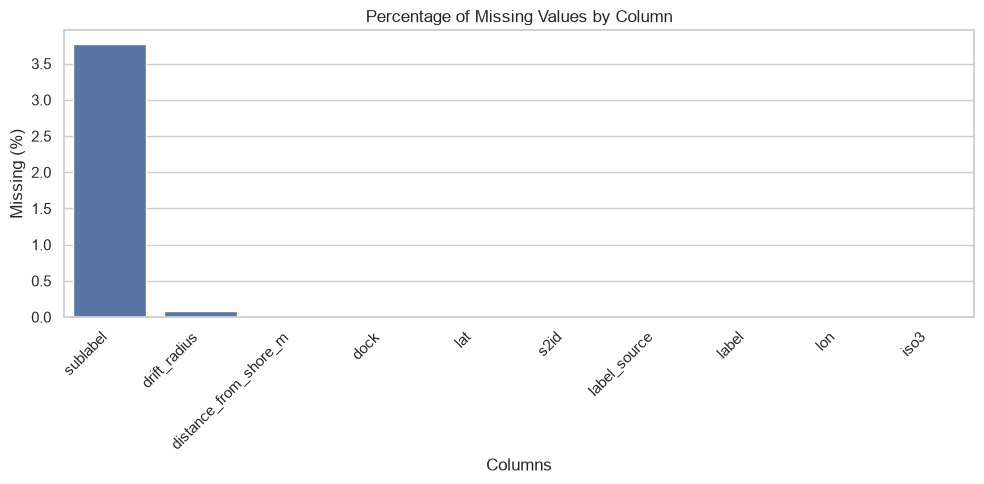


Total missing values: 6,482
Percentage of all missing values: 0.389%


In [6]:
# ============================================================
# Section 4.1 - Missing Data Analysis
# ============================================================

missing_values = ocean_data.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(ocean_data) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

print("=" * 70)
print("MISSING VALUES SUMMARY")
print("=" * 70)

display(missing_summary)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing Percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing (%)")
plt.xlabel("Columns")
plt.title("Percentage of Missing Values by Column")

plt.tight_layout()
plt.show()
print(f"\nTotal missing values: {missing_values.sum():,}")
print(f"Percentage of all missing values: {(missing_values.sum() / ocean_data.size) * 100:.3f}%")

### Discussion

The missing-value analysis indicates that the dataset is highly complete. Six out of the ten variables contain no missing values, while the remaining four variables contain only a small proportion of missing observations.

The `sublabel` column has the highest number of missing values, with **6,284 records (3.77%)**. Since `sublabel` provides a more detailed description of an anchorage, its absence does not necessarily indicate missing geographical information because the main anchorage label (`label`) is complete for all records. Therefore, many of these missing values are likely structural rather than random.

The remaining missing values are very limited:
- `drift_radius`: **153 records (0.09%)**
- `distance_from_shore_m`: **25 records (0.02%)**
- `dock`: **20 records (0.01%)**

These percentages are sufficiently small that they are unlikely to significantly influence the overall statistical analysis.

The missing-value pattern does not suggest a widespread data-quality problem. Instead, the missing observations appear to be concentrated in specific variables, indicating that the missingness is more likely related to differences in data availability or measurement processes than to systematic corruption of the dataset.

The missing values themselves may provide useful information. For example, missing values in `sublabel` may indicate that a more specific anchorage name was unavailable or could not be confidently assigned. Similarly, missing operational measurements such as `drift_radius` or `distance_from_shore_m` may reflect situations in which these quantities could not be reliably estimated.

If preprocessing were required, different strategies would be appropriate depending on the variable type:

- Numerical variables (`drift_radius`, `distance_from_shore_m`): median imputation would be appropriate because it is robust to outliers.
- Categorical variables (`sublabel`): introducing an **"Unknown"** category would preserve all observations without creating artificial values.
- Boolean variables (`dock`): the small number of missing values could either be removed or replaced after examining the distribution of existing values.

Overall, the dataset demonstrates a high level of completeness and is well suited for further exploratory data analysis.

## 4.2 Duplicate Records Analysis

Duplicate records may indicate data collection errors, repeated measurements, or valid repeated observations. This section examines both complete and partial duplicates, evaluates whether they contain useful information, and discusses whether they should be removed before further analysis.

In [7]:
# ============================================================
# Section 4.2 - Duplicate Records Analysis
# ============================================================

# ----- Complete duplicates -----
complete_duplicates = ocean_data.duplicated()

num_complete_duplicates = complete_duplicates.sum()
pct_complete_duplicates = (num_complete_duplicates / len(ocean_data)) * 100

print("=" * 70)
print("COMPLETE DUPLICATES")
print("=" * 70)

print(f"Number of complete duplicate rows : {num_complete_duplicates:,}")
print(f"Percentage of dataset             : {pct_complete_duplicates:.4f}%")

# ----- Partial duplicates (same anchorage ID) -----
partial_duplicates = ocean_data.duplicated(subset=["s2id"])

num_partial_duplicates = partial_duplicates.sum()
pct_partial_duplicates = (num_partial_duplicates / len(ocean_data)) * 100

print("\n" + "=" * 70)
print("PARTIAL DUPLICATES (SAME s2id)")
print("=" * 70)

print(f"Number of duplicated s2id values  : {num_partial_duplicates:,}")
print(f"Percentage of dataset             : {pct_partial_duplicates:.4f}%")

# Display examples if they exist
if num_complete_duplicates > 0:
    print("\nExamples of complete duplicates:")
    display(ocean_data[complete_duplicates].head())

if num_partial_duplicates > 0:
    print("\nExamples of duplicated s2id values:")
    display(
        ocean_data[
            ocean_data.duplicated(subset=["s2id"], keep=False)
        ].sort_values("s2id").head(10)
    )

COMPLETE DUPLICATES
Number of complete duplicate rows : 0
Percentage of dataset             : 0.0000%

PARTIAL DUPLICATES (SAME s2id)
Number of duplicated s2id values  : 0
Percentage of dataset             : 0.0000%


### Discussion

Complete duplicates represent rows that are identical across all variables. Such duplicates may indicate repeated data imports or data integration issues. If they exist, they should generally be removed because they do not provide additional information.

Partial duplicates require more careful interpretation. In this dataset, the analysis considers repeated values of the unique anchorage identifier (`s2id`). Since `s2id` is intended to uniquely identify each anchorage location, duplicated identifiers may indicate inconsistencies that should be investigated before further analysis.

If no duplicate records are found, this suggests that the dataset has good structural integrity and that each anchorage is represented only once.

If duplicated identifiers are found but the remaining variables differ, they should not be removed automatically. Instead, the differences should be examined to determine whether they represent updated records, conflicting information, or data-quality problems.

The decision to remove duplicates should therefore depend on the type of duplication and the information contained in the duplicated records rather than on duplication alone.

## 4.3 Suspicious Values Analysis

This section investigates values that may indicate data-quality problems or inconsistencies. The analysis focuses on impossible values, placeholder values, unreasonable numerical values, and whether these observations provide useful information about the dataset or the underlying data-collection process.

In [10]:
# ============================================================
# Section 4.3 - Suspicious Values Analysis
# ============================================================

print("=" * 70)
print("SUSPICIOUS VALUES ANALYSIS")
print("=" * 70)

# Placeholder values
placeholder_values = ["Unknown", "unknown", "N/A", "NA", "NULL", "null", "-", ""]

placeholder_summary = {}

for column in ocean_data.columns:
    placeholder_summary[column] = ocean_data[column].isin(placeholder_values).sum()

placeholder_summary = pd.DataFrame.from_dict(
    placeholder_summary,
    orient="index",
    columns=["Placeholder Values"]
)

print("\nPlaceholder Values")
display(placeholder_summary)

# Impossible geographic values
invalid_lat = ((ocean_data["lat"] < -90) | (ocean_data["lat"] > 90)).sum()
invalid_lon = ((ocean_data["lon"] < -180) | (ocean_data["lon"] > 180)).sum()

print("\nGeographical Validation")
print(f"Invalid latitude values  : {invalid_lat}")
print(f"Invalid longitude values : {invalid_lon}")

# Negative values
negative_distance = (ocean_data["distance_from_shore_m"] < 0).sum()
negative_drift = (ocean_data["drift_radius"] < 0).sum()

print("\nNegative Numerical Values")
print(f"Negative distance_from_shore_m : {negative_distance}")
print(f"Negative drift_radius          : {negative_drift}")

# Dock values
print("\nDock Values")
print(ocean_data["dock"].value_counts(dropna=False))
# Display invalid geographical records
invalid_geo = ocean_data[
    (ocean_data["lat"] < -90) |
    (ocean_data["lat"] > 90) |
    (ocean_data["lon"] < -180) |
    (ocean_data["lon"] > 180)
]
print("\nNumber of invalid geographical records:", len(invalid_geo))
if not invalid_geo.empty:
    print("\nInvalid geographical records:")
    display(invalid_geo)

SUSPICIOUS VALUES ANALYSIS

Placeholder Values


,Placeholder Values
s2id,0
lat,0
lon,0
label,0
sublabel,0
label_source,0
iso3,0
distance_from_shore_m,0
drift_radius,0
dock,0



Geographical Validation
Invalid latitude values  : 0
Invalid longitude values : 1

Negative Numerical Values
Negative distance_from_shore_m : 0
Negative drift_radius          : 0

Dock Values
dock
False    87939
True     78523
NaN         20
Name: count, dtype: int64

Number of invalid geographical records: 1

Invalid geographical records:


,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock
134276,8efe7543,11.84,"1,001.00",POINTE NOIRE,NaN,anchorage_overrides,COG,NaN,NaN,False


### Discussion

The suspicious-value analysis indicates that the dataset has a high overall level of data quality.

No placeholder values such as `"Unknown"`, `"N/A"`, `"NULL"`, or empty strings were detected in any column. This suggests that missing information is represented using proper missing values (`NaN`) rather than textual placeholders.

The geographical validation identified **one invalid longitude value**. The corresponding record has a longitude of **1001**, which is outside the valid geographical range of −180° to 180°. Since this issue appears in only one record out of more than 166,000 observations, it is most likely an isolated data-entry, formatting, or integration error rather than a systematic problem affecting the dataset.

Interestingly, the same record also contains missing values in both `sublabel` and `drift_radius`. This may indicate that the observation was manually corrected or imported from a source with incomplete information. The `label_source` value (`anchorage_overrides`) further suggests that this record originated from a manual correction process rather than from an automated data source.

No negative values were detected in either `distance_from_shore_m` or `drift_radius`, which is consistent with the physical meaning of these variables.

The `dock` variable contains only valid Boolean values (`True` and `False`) together with the previously identified missing values. No unexpected Boolean categories were found.

Overall, the dataset demonstrates excellent data quality. Apart from a single invalid longitude value, no suspicious numerical or categorical values were detected. The invalid record should be reviewed individually before performing geographical analyses, but its extremely low frequency means that it is unlikely to affect the overall conclusions of this study.conclusions of the analysis.

## 4.4 Cardinality Analysis

Cardinality describes the number of distinct values that appear in each variable. This analysis identifies columns with no variability as well as variables containing many unique values. Understanding cardinality is important because it affects data quality, feature engineering, storage efficiency, and the selection of appropriate statistical or machine-learning methods.

CARDINALITY ANALYSIS


,Unique Values,Data Type,Unique Percentage
s2id,166482,str,100.00
lat,166482,float64,100.00
lon,166481,float64,100.00
drift_radius,166330,float64,99.91
sublabel,31151,str,18.71
label,14618,str,8.78
distance_from_shore_m,279,float64,0.17
iso3,180,str,0.11
label_source,6,str,0.00
dock,3,object,0.00



COLUMNS WITH A SINGLE UNIQUE VALUE
No columns with a single unique value were found.

TOP 10 HIGHEST CARDINALITY COLUMNS


,Unique Values,Data Type,Unique Percentage
s2id,166482,str,100.00
lat,166482,float64,100.00
lon,166481,float64,100.00
drift_radius,166330,float64,99.91
sublabel,31151,str,18.71
label,14618,str,8.78
distance_from_shore_m,279,float64,0.17
iso3,180,str,0.11
label_source,6,str,0.00
dock,3,object,0.00


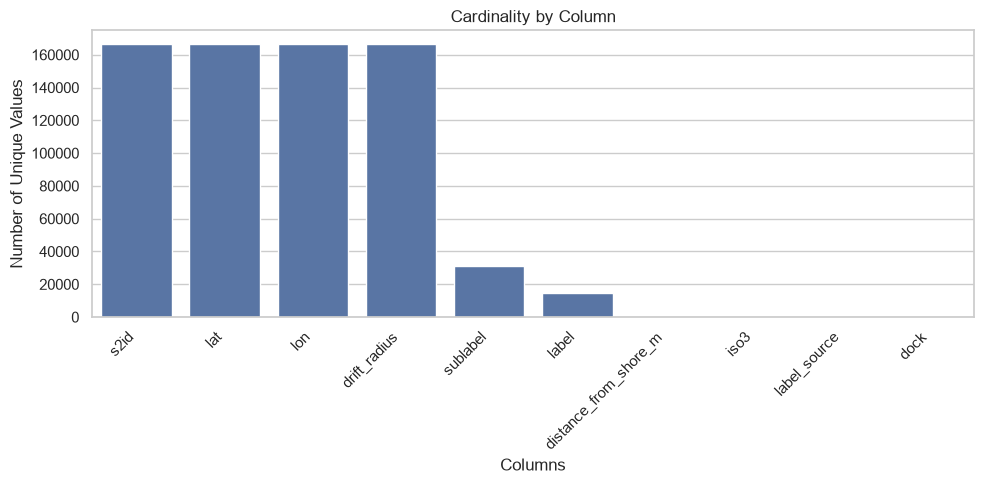

In [11]:
# ============================================================
# Section 4.4 - Cardinality Analysis
# ============================================================

cardinality = pd.DataFrame({
    "Unique Values": ocean_data.nunique(dropna=False),
    "Data Type": ocean_data.dtypes.astype(str)
})

cardinality["Unique Percentage"] = (
    cardinality["Unique Values"] / len(ocean_data) * 100
).round(2)

cardinality = cardinality.sort_values(
    by="Unique Values",
    ascending=False
)

print("=" * 70)
print("CARDINALITY ANALYSIS")
print("=" * 70)

display(cardinality)

# Columns with only one unique value
single_value_columns = cardinality[
    cardinality["Unique Values"] == 1
]

print("\n" + "=" * 70)
print("COLUMNS WITH A SINGLE UNIQUE VALUE")
print("=" * 70)

if single_value_columns.empty:
    print("No columns with a single unique value were found.")
else:
    display(single_value_columns)

# Top 10 highest-cardinality columns
print("\n" + "=" * 70)
print("TOP 10 HIGHEST CARDINALITY COLUMNS")
print("=" * 70)

display(cardinality.head(10))

# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=cardinality.reset_index(),
    x="index",
    y="Unique Values"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Unique Values")
plt.xlabel("Columns")
plt.title("Cardinality by Column")

plt.tight_layout()

plt.show()

### Discussion

The cardinality analysis reveals that the dataset contains variables with very different levels of uniqueness, reflecting the different roles of the variables within the dataset.

No column contains only a single unique value. This indicates that every variable contributes information and that there are no constant columns that should be removed before further analysis.

Several variables exhibit extremely high cardinality. The `s2id` column contains **166,482 unique values**, confirming that each anchorage is assigned a unique identifier. Similarly, both geographical coordinates (`lat` and `lon`) are almost entirely unique because each anchorage occupies a distinct geographic location. The `drift_radius` variable also has very high cardinality, indicating that it behaves as a continuous numerical measurement.

The `label` and `sublabel` variables have high but substantially lower cardinality. This suggests that many anchorages share common port names while still allowing more detailed location descriptions through the `sublabel` field.

The `iso3` variable contains **180 unique country codes**, making it suitable for country-level grouping and aggregation. The `label_source` variable contains only **six unique categories**, reflecting the limited number of data sources used to assign anchorage names.

Finally, the `dock` variable contains only three distinct values (`True`, `False`, and missing values), confirming that it represents a low-cardinality Boolean feature.

Overall, the cardinality structure is consistent with the expected design of a geographical reference dataset and does not reveal any structural anomalies.

## 5.1 Univariate Analysis of Numerical Variables

This section examines each numerical variable separately. The analysis includes measures of central tendency, dispersion, quantiles, skewness, distribution shape, and univariate outlier detection.

The numerical variables analyzed are `lat`, `lon`, `distance_from_shore_m`, and `drift_radius`. The `s2id` column is excluded because it is an identifier rather than a measurable numerical variable.

Three methods are used to identify potential outliers:

1. The Interquartile Range (IQR) method.
2. The standard Z-score method.
3. The Modified Z-score method based on the Median Absolute Deviation (MAD).

Outliers identified by these methods are treated as observations requiring investigation rather than automatically classified as errors.

DESCRIPTIVE STATISTICS


,Valid Values,Missing Values,Mean,Median,Standard Deviation,MAD,Minimum,Q1,Q2 (Median),Q3,Maximum,IQR,Skewness
Variable,,,,,,,,,,,,,
lat,166482,0,29.07,31.77,20.60,8.77,-54.94,22.89,31.77,40.38,79.56,17.49,-1.25
lon,166482,0,55.53,79.73,75.14,47.61,-179.94,5.32,79.73,119.99,"1,001.00",114.67,-0.68
distance_from_shore_m,166457,25,"5,663.08","1,000.00","14,587.58","1,000.00",0.00,0.00,"1,000.00","6,000.00","368,000.00","6,000.00",9.66
drift_radius,166329,153,0.10,0.10,0.04,0.03,0.00,0.07,0.10,0.13,0.30,0.06,0.47



SKEWNESS INTERPRETATION


,Skewness,Interpretation
Variable,,
lat,-1.25,Strong negative skew
lon,-0.68,Moderate negative skew
distance_from_shore_m,9.66,Strong positive skew
drift_radius,0.47,Approximately symmetric



OUTLIER DETECTION SUMMARY


,IQR Lower Bound,IQR Upper Bound,IQR Outliers,IQR Outliers (%),Z-Score Outliers,Z-Score Outliers (%),Modified Z-Score Outliers,Modified Z-Score Outliers (%)
Variable,,,,,,,,
lat,-3.34,66.61,14728,8.85,3410,2.05,10046,6.03
lon,-166.67,291.99,121,0.07,120,0.07,121,0.07
distance_from_shore_m,"-9,000.00","15,000.00",16848,10.12,1917,1.15,38702,23.25
drift_radius,-0.03,0.23,370,0.22,299,0.18,13,0.01



OUTLIERS DETECTED BY ALL THREE METHODS


,Outliers Detected by All Three Methods,Percentage of Valid Values
Variable,,
lat,3410,2.05
lon,120,0.07
distance_from_shore_m,1917,1.15
drift_radius,13,0.01


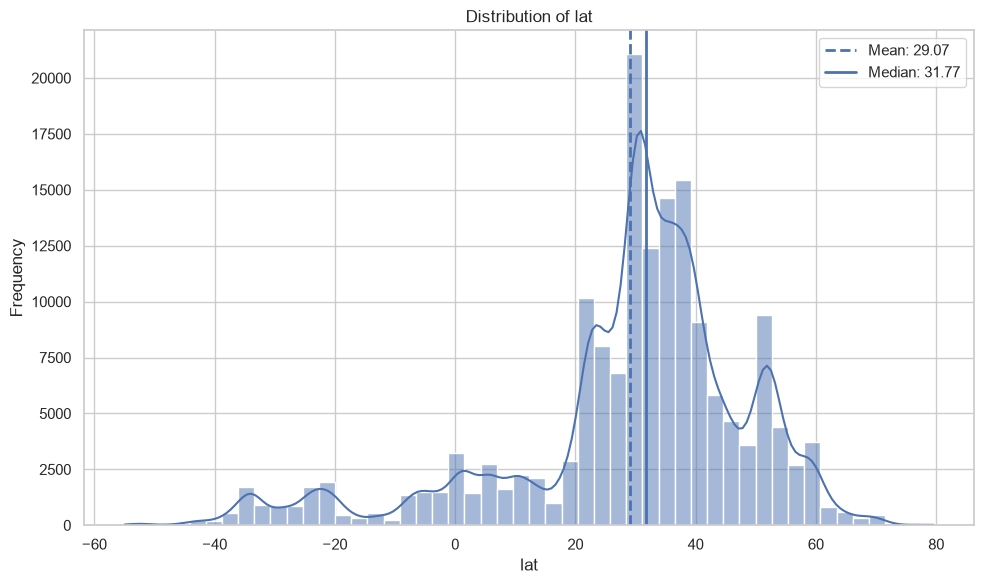

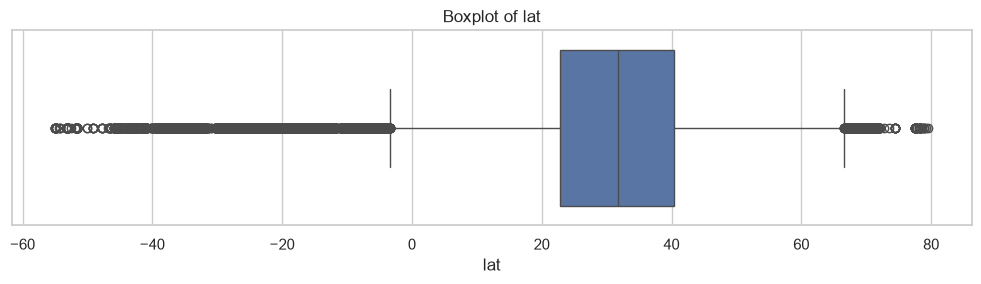

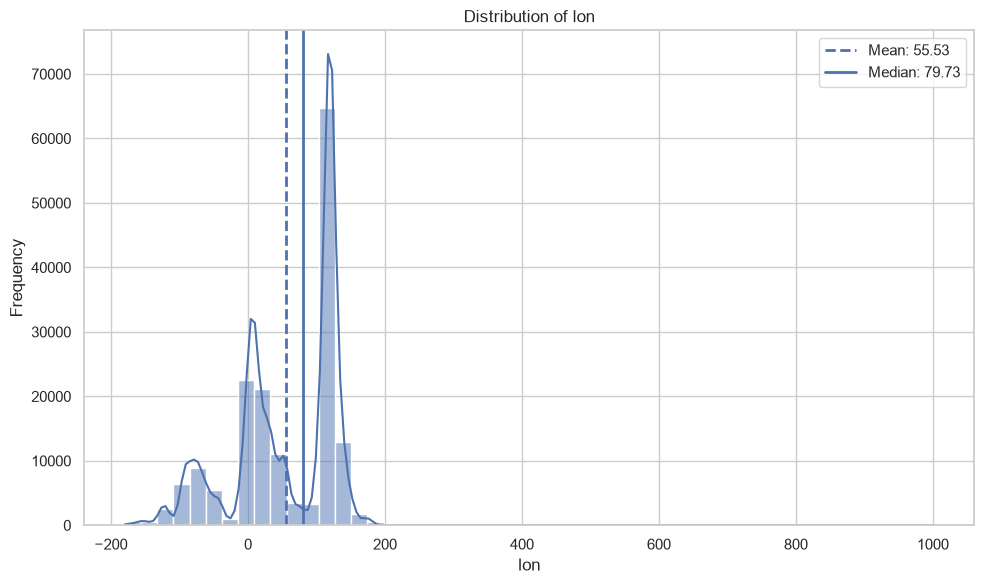

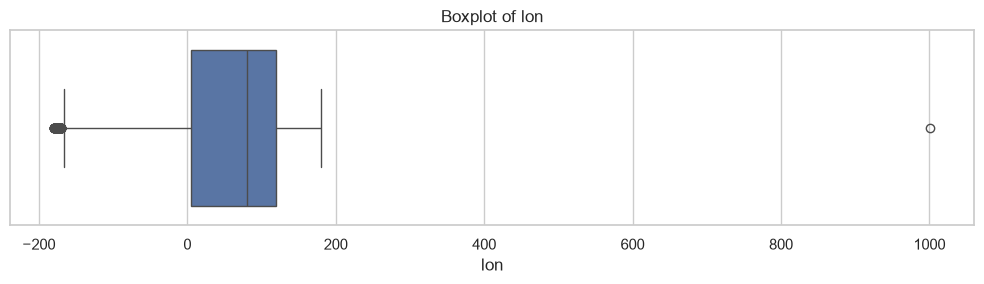

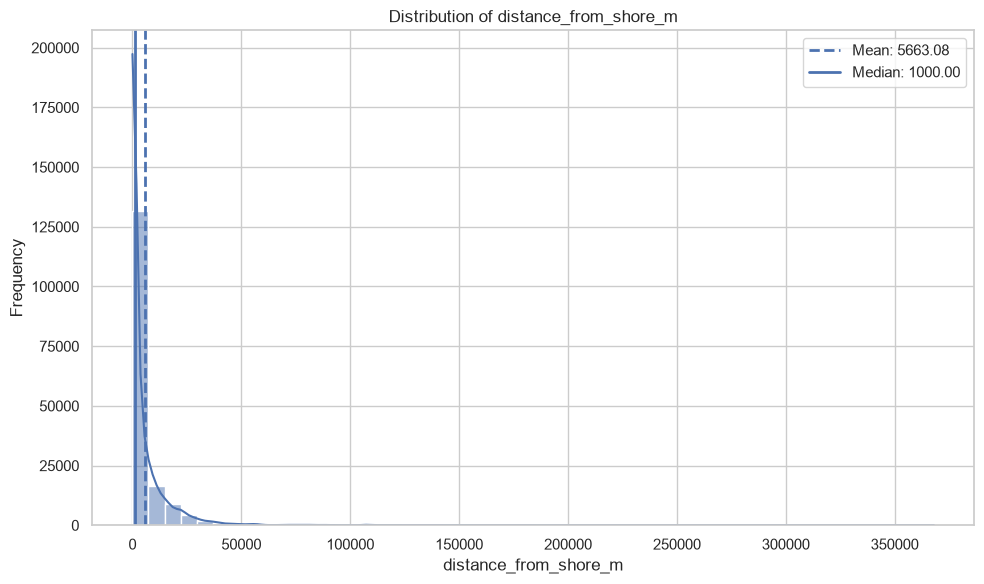

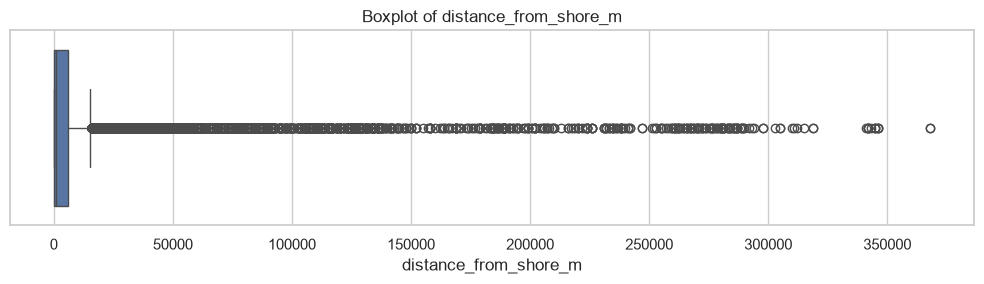

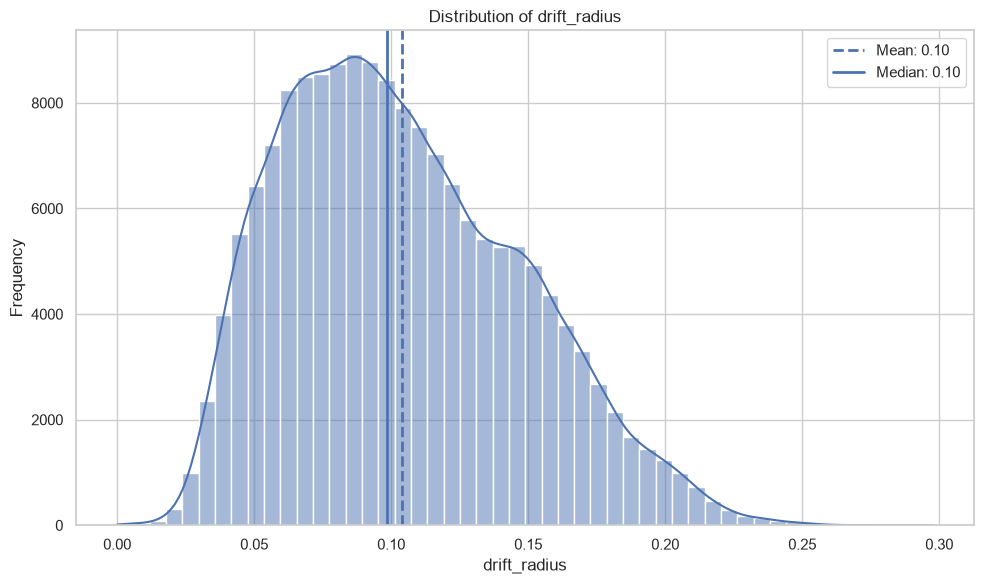

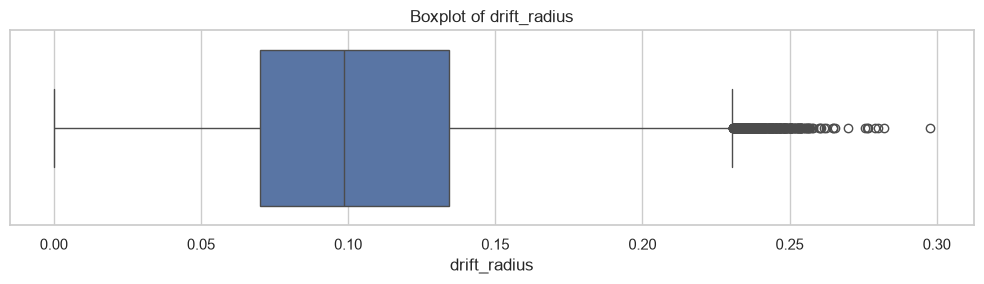


MOST EXTREME VALUES

Variable: lat


,s2id,label,iso3,lat
16734,bc4ddb4d,CHL-59,CHL,-54.94
83433,bc4eac75,PUERTO WILLIAMS,CHL,-54.93
83431,bc4eac77,PUERTO WILLIAMS,CHL,-54.93
83430,bc4eac79,PUERTO WILLIAMS,CHL,-54.93
16633,bc4c28dd,CHL-4,CHL,-54.93
120187,4582b067,NY ALESUND,NOR,78.93
120188,4582b065,NY ALESUND,NOR,78.93
67922,4582b027,SJM-10,NOR,78.96
44437,4f787e21,GRL-21,DNK,79.17
67921,45784285,SJM-4,NOR,79.56



Variable: lon


,s2id,label,iso3,lon
40238,71dffeb3,FJI-60,FJI,-179.94
40254,71e004e5,FJI-48,FJI,-179.89
40313,71e0121f,FJI-31,FJI,-179.77
40303,71e0127b,FJI-58,FJI,-179.74
66307,5755b943,EGVEKINOT,RUS,-179.11
40270,6e1fe51f,FJI-38,FJI,179.89
40269,6e1fe4e7,FJI-38,FJI,179.90
40282,6e1fdd97,FJI-30,FJI,179.90
40268,6e1fe4e9,FJI-38,FJI,179.90
134276,8efe7543,POINTE NOIRE,COG,"1,001.00"



Variable: distance_from_shore_m


,s2id,label,iso3,distance_from_shore_m
0,477eac73,ITA-196,ITA,0.00
1,3442a529,TAMSUI FISH WHARF,TWN,0.00
2,3442a52f,TAMSUI FISH WHARF,TWN,0.00
3,3442a4d5,TAMSUI FISH WHARF,TWN,0.00
4,3442a4d7,TAMSUI FISH WHARF,TWN,0.00
76418,861ae941,FOURCHON ANCHORAGE,USA,"346,000.00"
76420,861ae93f,FOURCHON ANCHORAGE,USA,"346,000.00"
76419,861ae943,FOURCHON ANCHORAGE,USA,"346,000.00"
35426,7142621b,COK-1,COK,"368,000.00"
35425,71426205,COK-1,COK,"368,000.00"



Variable: drift_radius


,s2id,label,iso3,drift_radius
25793,35c9a923,CHN-2540,CHN,0.00
64008,41566dd3,RUS-479,RUS,0.00
53380,3518a823,JPN-9,JPN,0.00
25794,35c9a925,CHN-2540,CHN,0.00
72887,346f2105,TWN-NA,TWN,0.00
7131,31d20301,FORTUNE STAR,MYS,0.28
58224,31d20479,SUNGAI LINGGI,MYS,0.28
99984,480a6405,OUISTREHAM,FRA,0.28
58223,31d2046f,SUNGAI LINGGI,MYS,0.28
7130,31d20305,FORTUNE STAR,MYS,0.30


In [12]:
# ============================================================
# Section 5.1 - Univariate Analysis of Numerical Variables
# ============================================================

numeric_columns = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------

descriptive_rows = []

for column in numeric_columns:
    series = ocean_data[column].dropna()

    mean_value = series.mean()
    median_value = series.median()
    standard_deviation = series.std()
    mad_value = np.median(np.abs(series - median_value))

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_value = q3 - q1

    descriptive_rows.append({
        "Variable": column,
        "Valid Values": series.count(),
        "Missing Values": ocean_data[column].isna().sum(),
        "Mean": mean_value,
        "Median": median_value,
        "Standard Deviation": standard_deviation,
        "MAD": mad_value,
        "Minimum": series.min(),
        "Q1": q1,
        "Q2 (Median)": median_value,
        "Q3": q3,
        "Maximum": series.max(),
        "IQR": iqr_value,
        "Skewness": series.skew()
    })

descriptive_summary = pd.DataFrame(descriptive_rows).set_index("Variable")

print("=" * 90)
print("DESCRIPTIVE STATISTICS")
print("=" * 90)

display(descriptive_summary.round(3))


# ------------------------------------------------------------
# Skewness interpretation
# ------------------------------------------------------------

def interpret_skewness(skewness_value):
    if skewness_value > 1:
        return "Strong positive skew"
    if skewness_value > 0.5:
        return "Moderate positive skew"
    if skewness_value >= -0.5:
        return "Approximately symmetric"
    if skewness_value >= -1:
        return "Moderate negative skew"
    return "Strong negative skew"


skewness_summary = descriptive_summary[["Skewness"]].copy()
skewness_summary["Interpretation"] = skewness_summary["Skewness"].apply(
    interpret_skewness
)

print("\n" + "=" * 90)
print("SKEWNESS INTERPRETATION")
print("=" * 90)

display(skewness_summary.round(3))


# ------------------------------------------------------------
# Outlier detection using three methods
# ------------------------------------------------------------

outlier_rows = []

for column in numeric_columns:
    series = ocean_data[column].dropna()

    # Method 1: IQR
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_value = q3 - q1

    iqr_lower_bound = q1 - 1.5 * iqr_value
    iqr_upper_bound = q3 + 1.5 * iqr_value

    iqr_mask = (
        (series < iqr_lower_bound) |
        (series > iqr_upper_bound)
    )

    # Method 2: Standard Z-score
    if series.std() == 0:
        z_score_mask = pd.Series(False, index=series.index)
    else:
        z_scores = np.abs(stats.zscore(series, nan_policy="omit"))
        z_score_mask = pd.Series(z_scores > 3, index=series.index)

    # Method 3: Modified Z-score using MAD
    median_value = series.median()
    mad_value = np.median(np.abs(series - median_value))

    if mad_value == 0:
        modified_z_score_mask = pd.Series(False, index=series.index)
    else:
        modified_z_scores = (
            0.6745 * (series - median_value) / mad_value
        ).abs()

        modified_z_score_mask = modified_z_scores > 3.5

    outlier_rows.append({
        "Variable": column,
        "IQR Lower Bound": iqr_lower_bound,
        "IQR Upper Bound": iqr_upper_bound,
        "IQR Outliers": int(iqr_mask.sum()),
        "IQR Outliers (%)": iqr_mask.mean() * 100,
        "Z-Score Outliers": int(z_score_mask.sum()),
        "Z-Score Outliers (%)": z_score_mask.mean() * 100,
        "Modified Z-Score Outliers": int(modified_z_score_mask.sum()),
        "Modified Z-Score Outliers (%)": modified_z_score_mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index("Variable")

print("\n" + "=" * 90)
print("OUTLIER DETECTION SUMMARY")
print("=" * 90)

display(outlier_summary.round(3))


# ------------------------------------------------------------
# Compare observations detected by all three methods
# ------------------------------------------------------------

agreement_rows = []

for column in numeric_columns:
    series = ocean_data[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_value = q3 - q1

    iqr_mask = (
        (series < q1 - 1.5 * iqr_value) |
        (series > q3 + 1.5 * iqr_value)
    )

    if series.std() == 0:
        z_score_mask = pd.Series(False, index=series.index)
    else:
        z_scores = np.abs(stats.zscore(series, nan_policy="omit"))
        z_score_mask = pd.Series(z_scores > 3, index=series.index)

    median_value = series.median()
    mad_value = np.median(np.abs(series - median_value))

    if mad_value == 0:
        modified_z_score_mask = pd.Series(False, index=series.index)
    else:
        modified_z_scores = (
            0.6745 * (series - median_value) / mad_value
        ).abs()

        modified_z_score_mask = modified_z_scores > 3.5

    all_three_methods = (
        iqr_mask &
        z_score_mask &
        modified_z_score_mask
    )

    agreement_rows.append({
        "Variable": column,
        "Outliers Detected by All Three Methods": int(
            all_three_methods.sum()
        ),
        "Percentage of Valid Values": (
            all_three_methods.mean() * 100
        )
    })

agreement_summary = pd.DataFrame(agreement_rows).set_index("Variable")

print("\n" + "=" * 90)
print("OUTLIERS DETECTED BY ALL THREE METHODS")
print("=" * 90)

display(agreement_summary.round(3))


# ------------------------------------------------------------
# Distribution plots
# ------------------------------------------------------------

for column in numeric_columns:
    clean_series = ocean_data[column].dropna()

    plt.figure(figsize=(10, 6))

    sns.histplot(
        clean_series,
        bins=50,
        kde=True
    )

    plt.axvline(
        clean_series.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean: {clean_series.mean():.2f}"
    )

    plt.axvline(
        clean_series.median(),
        linestyle="-",
        linewidth=2,
        label=f"Median: {clean_series.median():.2f}"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=clean_series
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Display the most extreme observations
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MOST EXTREME VALUES")
print("=" * 90)

for column in numeric_columns:
    print(f"\nVariable: {column}")

    extreme_values = pd.concat([
        ocean_data.nsmallest(5, column),
        ocean_data.nlargest(5, column)
    ]).drop_duplicates()

    display(
        extreme_values[
            [
                "s2id",
                "label",
                "iso3",
                column
            ]
        ].sort_values(column)
    )

### Discussion

The numerical variables exhibit substantially different statistical characteristics, reflecting the diverse nature of the measurements contained in the dataset.

The latitude (`lat`) variable has a mean of **29.07°** and a median of **31.77°**, indicating a negatively skewed distribution. This is consistent with the geographical distribution of global anchorages, where a large proportion of ports are located in the Northern Hemisphere.

Longitude (`lon`) also shows a moderate negative skew. Most longitude values fall within the valid geographical range, while a single extreme value (1001°) was identified as an invalid observation during the previous data-quality analysis. This single erroneous value slightly increases the maximum value and should be treated as a data-quality issue rather than a genuine geographical observation.

The `distance_from_shore_m` variable exhibits a very strong positive skew (Skewness = **9.66**). The median distance is only **1,000 meters**, whereas the mean exceeds **5,600 meters**, indicating that most anchorages are located relatively close to the shoreline while a small number of anchorages are located much farther offshore.

The `drift_radius` variable is approximately symmetric, with very similar mean and median values. This suggests that vessel drift radii are relatively consistent across most anchorage locations.

Three different outlier detection methods were applied:

- **Interquartile Range (IQR)**
- **Standard Z-score**
- **Modified Z-score (MAD)**

The results demonstrate that the number of detected outliers depends strongly on the detection method. The IQR method identifies more observations as outliers for highly skewed variables, whereas the Z-score method is more conservative. The Modified Z-score provides a robust alternative because it is based on the median rather than the mean.

For the `distance_from_shore_m` variable, the large number of detected outliers most likely represents genuine offshore anchorage locations rather than measurement errors. Similarly, extreme latitude values correspond to real locations in northern and southern regions of the world rather than invalid observations.

Overall, the distributions indicate that most extreme values represent legitimate geographical variability instead of incorrect measurements. Therefore, potential outliers should be investigated individually before considering their removal.

## 5.2 Univariate Analysis of Categorical Variables

This section analyzes the categorical variables in the dataset. The analysis examines category frequencies, identifies the most common categories, evaluates the minimum number of categories required to represent most of the observations, and investigates the presence of rare categories.

The following categorical variables are analyzed:

- `label`
- `sublabel`
- `label_source`
- `iso3`
- `dock`

The identifier `s2id` is excluded because it uniquely identifies each observation and does not represent a meaningful category.


CATEGORICAL VARIABLE: LABEL

FREQUENCY TABLE - TOP 20 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
label,,,
SHANGHAI,3260,1.96,1.96
NINGBO,1869,1.12,3.08
TIANJIN,1449,0.87,3.95
GUANGZHOU,1272,0.76,4.72
ZHOUSHAN,1107,0.66,5.38
KAVKAZ,991,0.60,5.98
QINHUANGDAO,981,0.59,6.56
HUANGHUA,980,0.59,7.15
SINGAPORE,874,0.53,7.68



MOST FREQUENT CATEGORY
Value       : SHANGHAI
Frequency   : 3,260
Percentage  : 1.9582%

TOP 10 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
label,,,
SHANGHAI,3260,1.96,1.96
NINGBO,1869,1.12,3.08
TIANJIN,1449,0.87,3.95
GUANGZHOU,1272,0.76,4.72
ZHOUSHAN,1107,0.66,5.38
KAVKAZ,991,0.60,5.98
QINHUANGDAO,981,0.59,6.56
HUANGHUA,980,0.59,7.15
SINGAPORE,874,0.53,7.68


The top 10 categories represent 8.2021% of the dataset.

MINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT AT LEAST 90% OF THE DATA
Number of categories : 4,507
Coverage achieved    : 90.0019%

The complete coverage set is large. Its first 20 and last 10 categories are displayed below.

First 20 categories in the coverage set:


,Count,Percentage (%),Cumulative Percentage (%)
label,,,
SHANGHAI,3260,1.96,1.96
NINGBO,1869,1.12,3.08
TIANJIN,1449,0.87,3.95
GUANGZHOU,1272,0.76,4.72
ZHOUSHAN,1107,0.66,5.38
KAVKAZ,991,0.60,5.98
QINHUANGDAO,981,0.59,6.56
HUANGHUA,980,0.59,7.15
SINGAPORE,874,0.53,7.68



Last 10 categories required to reach the target:


,Count,Percentage (%),Cumulative Percentage (%)
label,,,
PRY-13,4,0.00,89.98
RANGIROA,4,0.00,89.98
PYF-36,4,0.00,89.99
PYF-26,4,0.00,89.99
AL RUWAIS,4,0.00,89.99
ROU-45,4,0.00,89.99
GIURGIULESTI,4,0.00,89.99
ALEKSEEVSK,4,0.00,90.00
BALAKHNA,4,0.00,90.00



The complete list is stored in categorical_coverage_tables['label'].

RARE CATEGORIES (DEFINED AS 5 OR FEWER OBSERVATIONS)
Number of rare categories       : 11,111
Observations in rare categories : 21,227
Dataset percentage represented  : 12.7503%

Examples of rare categories:


,Count,Percentage (%),Cumulative Percentage (%)
label,,,
TAMSUI FISH WHARF,5,0.00,87.25
CHN-2332,5,0.00,87.26
BAKERS BAY,5,0.00,87.26
CAN-44,5,0.00,87.26
CAN-56,5,0.00,87.26
PORT MOUTON,5,0.00,87.27
CHN-2088,5,0.00,87.27
CHN-2177,5,0.00,87.27
CHN-787,5,0.00,87.28


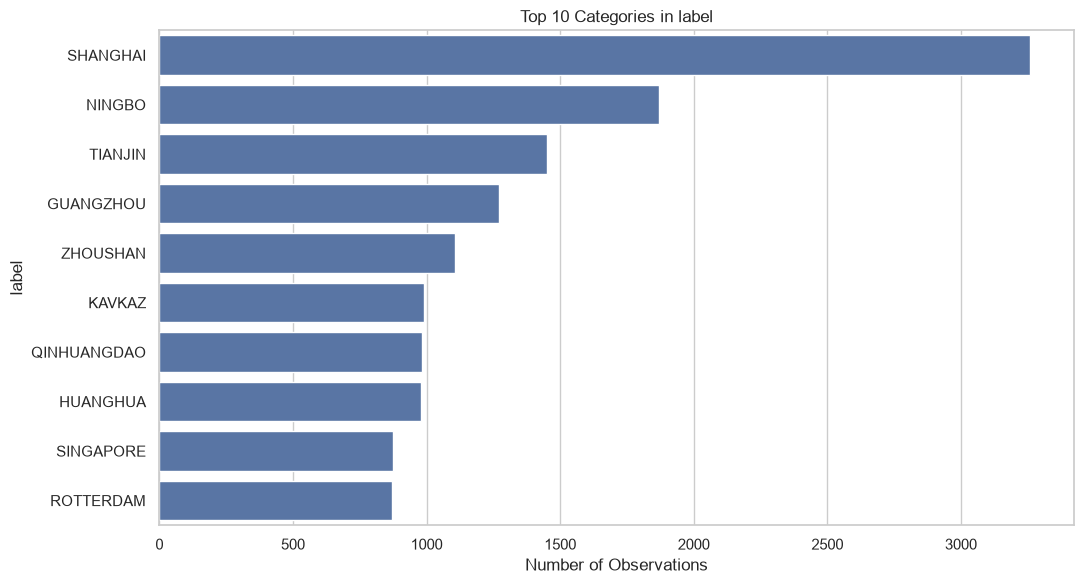


CATEGORICAL VARIABLE: SUBLABEL

FREQUENCY TABLE - TOP 20 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
sublabel,,,
<MISSING>,6284,3.77,3.77
ZHOUSHAN,4565,2.74,6.52
SHANGHAI,3216,1.93,8.45
TANGSHAN,1747,1.05,9.50
SINGAPORE,1600,0.96,10.46
ZHUHAI,1366,0.82,11.28
TAIZHOU,1299,0.78,12.06
NINGBO,1225,0.74,12.80
TIANJIN,1213,0.73,13.52



MOST FREQUENT CATEGORY
Value       : <MISSING>
Frequency   : 6,284
Percentage  : 3.7746%

TOP 10 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
sublabel,,,
<MISSING>,6284,3.77,3.77
ZHOUSHAN,4565,2.74,6.52
SHANGHAI,3216,1.93,8.45
TANGSHAN,1747,1.05,9.50
SINGAPORE,1600,0.96,10.46
ZHUHAI,1366,0.82,11.28
TAIZHOU,1299,0.78,12.06
NINGBO,1225,0.74,12.80
TIANJIN,1213,0.73,13.52


The top 10 categories represent 14.1859% of the dataset.

MINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT AT LEAST 90% OF THE DATA
Number of categories : 14,503
Coverage achieved    : 90.0001%

The complete coverage set is large. Its first 20 and last 10 categories are displayed below.

First 20 categories in the coverage set:


,Count,Percentage (%),Cumulative Percentage (%)
sublabel,,,
<MISSING>,6284,3.77,3.77
ZHOUSHAN,4565,2.74,6.52
SHANGHAI,3216,1.93,8.45
TANGSHAN,1747,1.05,9.50
SINGAPORE,1600,0.96,10.46
ZHUHAI,1366,0.82,11.28
TAIZHOU,1299,0.78,12.06
NINGBO,1225,0.74,12.80
TIANJIN,1213,0.73,13.52



Last 10 categories required to reach the target:


,Count,Percentage (%),Cumulative Percentage (%)
sublabel,,,
36ab5a51,1,0.00,89.99
36ab5a67,1,0.00,90.00
36ab5a5d,1,0.00,90.00
36ab5bab,1,0.00,90.00
36ab5a65,1,0.00,90.00
36ab5a5b,1,0.00,90.00
344cac5f,1,0.00,90.00
35b31107,1,0.00,90.00
35b311b3,1,0.00,90.00



The complete list is stored in categorical_coverage_tables['sublabel'].

RARE CATEGORIES (DEFINED AS 5 OR FEWER OBSERVATIONS)
Number of rare categories       : 27,786
Observations in rare categories : 36,894
Dataset percentage represented  : 22.1610%

Examples of rare categories:


,Count,Percentage (%),Cumulative Percentage (%)
sublabel,,,
SOKHNA,5,0.00,77.84
RICHMOND,5,0.00,77.85
MOVILLE,5,0.00,77.85
CD CARMEN,5,0.00,77.85
BIESBOSCH,5,0.00,77.85
KOKAR,5,0.00,77.86
SEA,5,0.00,77.86
NORTH SAANICH,5,0.00,77.86
KOREA,5,0.00,77.87


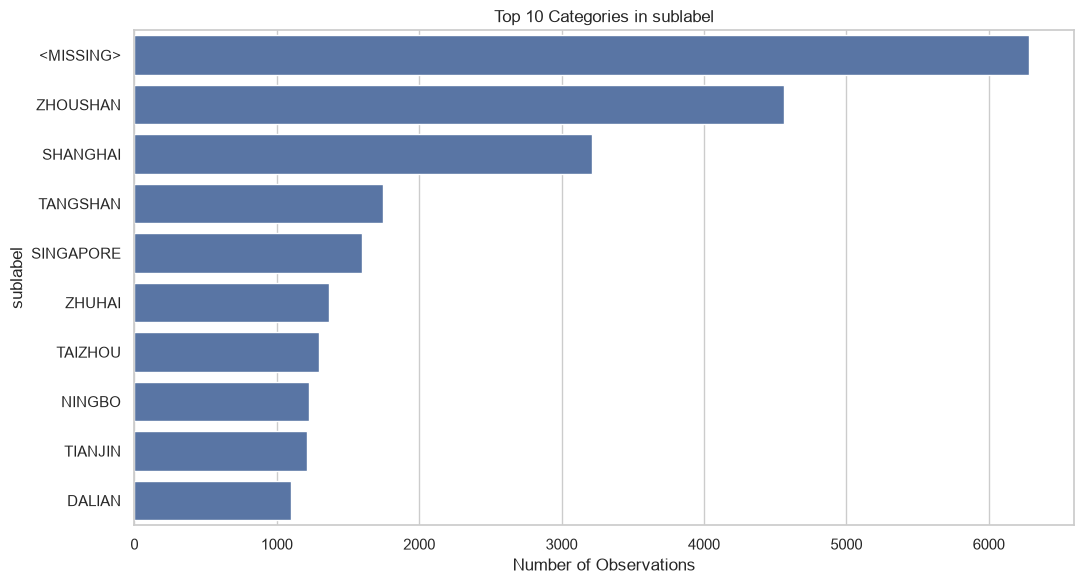


CATEGORICAL VARIABLE: LABEL_SOURCE

FREQUENCY TABLE - TOP 20 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
label_source,,,
anchorage_overrides,126333,75.88,75.88
top_destination,19077,11.46,87.34
WPI_ports,13314,8.00,95.34
geonames_1000,7675,4.61,99.95
indonesia,74,0.04,99.99
peru,9,0.01,100.00



MOST FREQUENT CATEGORY
Value       : anchorage_overrides
Frequency   : 126,333
Percentage  : 75.8839%

TOP 6 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
label_source,,,
anchorage_overrides,126333,75.88,75.88
top_destination,19077,11.46,87.34
WPI_ports,13314,8.00,95.34
geonames_1000,7675,4.61,99.95
indonesia,74,0.04,99.99
peru,9,0.01,100.00


The top 6 categories represent 100.0000% of the dataset.

MINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT AT LEAST 90% OF THE DATA
Number of categories : 3
Coverage achieved    : 95.3400%

Categories included in the coverage set:


,Count,Percentage (%),Cumulative Percentage (%)
label_source,,,
anchorage_overrides,126333,75.88,75.88
top_destination,19077,11.46,87.34
WPI_ports,13314,8.00,95.34



RARE CATEGORIES (DEFINED AS 5 OR FEWER OBSERVATIONS)
Number of rare categories       : 0
Observations in rare categories : 0
Dataset percentage represented  : 0.0000%
No rare categories were detected using this definition.


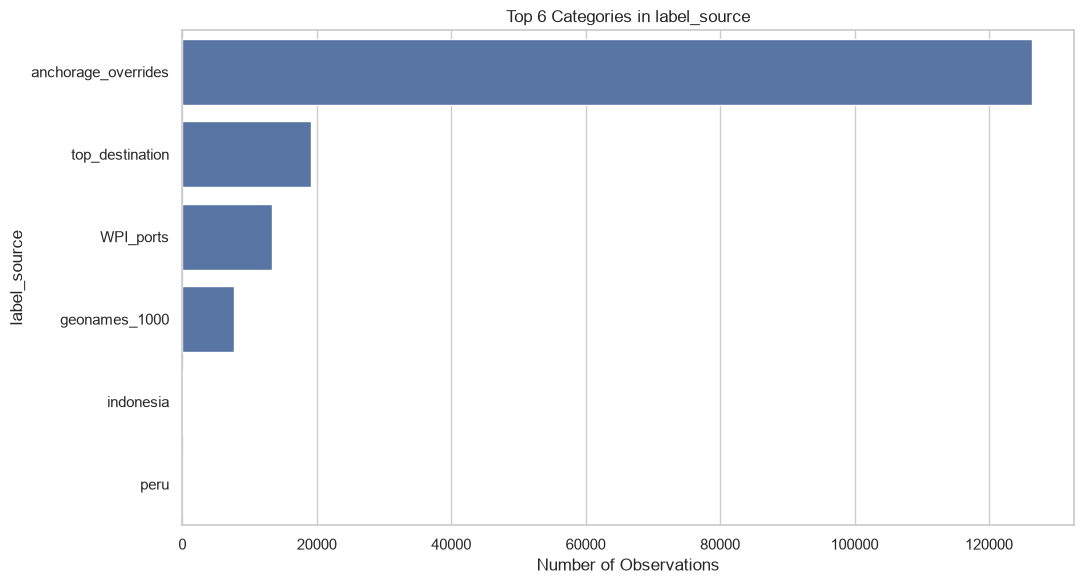

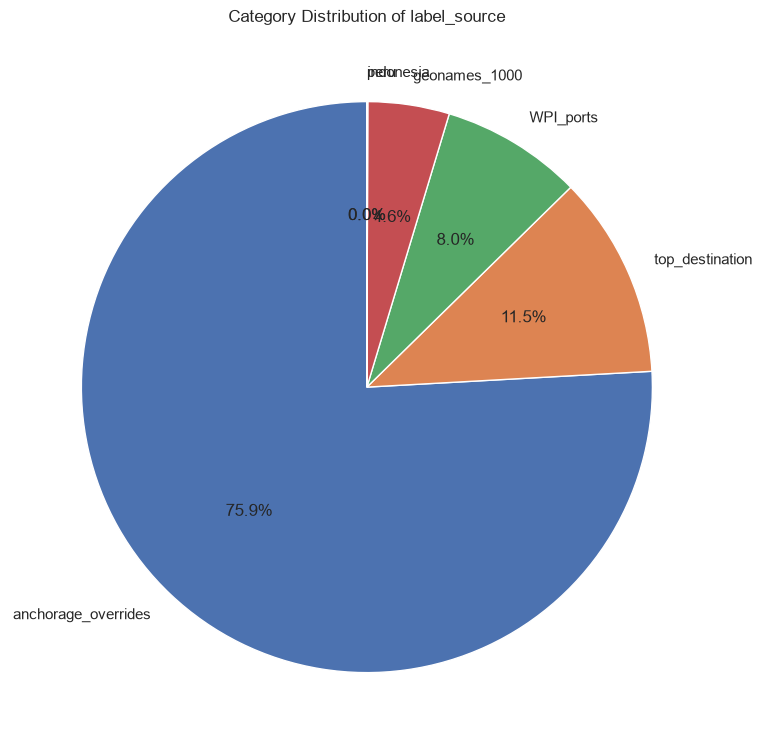


CATEGORICAL VARIABLE: ISO3

FREQUENCY TABLE - TOP 20 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
iso3,,,
CHN,54385,32.67,32.67
USA,11128,6.68,39.35
JPN,8513,5.11,44.46
NLD,5049,3.03,47.50
RUS,4278,2.57,50.07
IDN,4160,2.50,52.57
DEU,3506,2.11,54.67
FRA,3434,2.06,56.73
GBR,3408,2.05,58.78



MOST FREQUENT CATEGORY
Value       : CHN
Frequency   : 54,385
Percentage  : 32.6672%

TOP 10 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
iso3,,,
CHN,54385,32.67,32.67
USA,11128,6.68,39.35
JPN,8513,5.11,44.46
NLD,5049,3.03,47.50
RUS,4278,2.57,50.07
IDN,4160,2.50,52.57
DEU,3506,2.11,54.67
FRA,3434,2.06,56.73
GBR,3408,2.05,58.78


The top 10 categories represent 60.7922% of the dataset.

MINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT AT LEAST 90% OF THE DATA
Number of categories : 43
Coverage achieved    : 90.0314%

The complete coverage set is large. Its first 20 and last 10 categories are displayed below.

First 20 categories in the coverage set:


,Count,Percentage (%),Cumulative Percentage (%)
iso3,,,
CHN,54385,32.67,32.67
USA,11128,6.68,39.35
JPN,8513,5.11,44.46
NLD,5049,3.03,47.50
RUS,4278,2.57,50.07
IDN,4160,2.50,52.57
DEU,3506,2.11,54.67
FRA,3434,2.06,56.73
GBR,3408,2.05,58.78



Last 10 categories required to reach the target:


,Count,Percentage (%),Cumulative Percentage (%)
iso3,,,
THA,847,0.51,86.31
ARG,807,0.48,86.80
IRN,738,0.44,87.24
MLT,712,0.43,87.67
PAN,699,0.42,88.09
VEN,687,0.41,88.50
HRV,680,0.41,88.91
TGO,662,0.40,89.31
VNM,617,0.37,89.68



The complete list is stored in categorical_coverage_tables['iso3'].

RARE CATEGORIES (DEFINED AS 5 OR FEWER OBSERVATIONS)
Number of rare categories       : 14
Observations in rare categories : 34
Dataset percentage represented  : 0.0204%

Examples of rare categories:


,Count,Percentage (%),Cumulative Percentage (%)
iso3,,,
PLW,5,0.00,99.98
STP,4,0.00,99.98
WSM,4,0.00,99.99
CZE,3,0.00,99.99
MDA,3,0.00,99.99
NIU,3,0.00,99.99
CXR,2,0.00,99.99
BLM,2,0.00,100.00
MNP,2,0.00,100.00


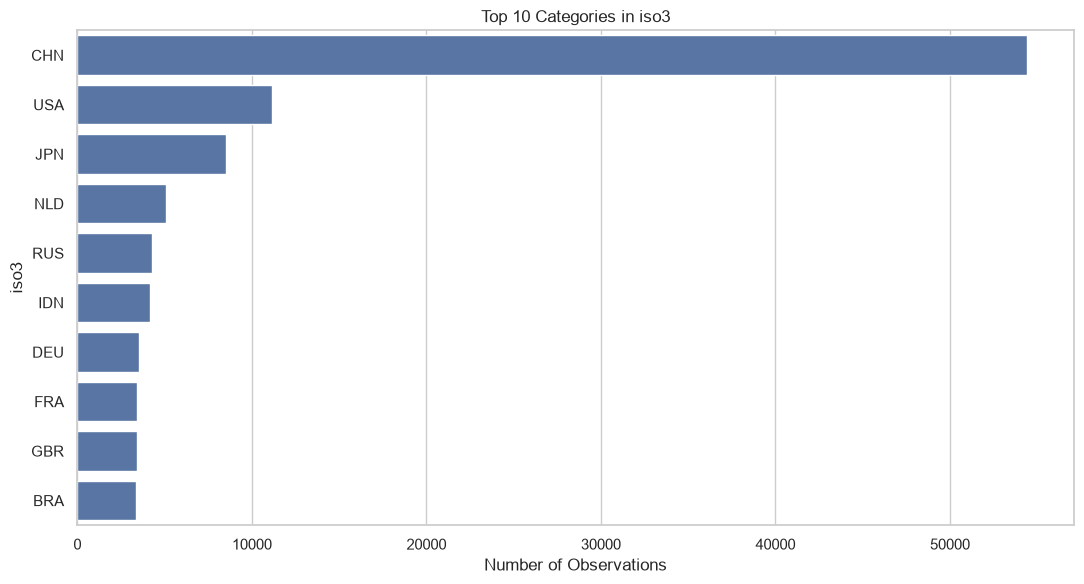


CATEGORICAL VARIABLE: DOCK

FREQUENCY TABLE - TOP 20 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
dock,,,
False,87939,52.82,52.82
True,78523,47.17,99.99
<MISSING>,20,0.01,100.00



MOST FREQUENT CATEGORY
Value       : False
Frequency   : 87,939
Percentage  : 52.8219%

TOP 3 CATEGORIES


,Count,Percentage (%),Cumulative Percentage (%)
dock,,,
False,87939,52.82,52.82
True,78523,47.17,99.99
<MISSING>,20,0.01,100.00


The top 3 categories represent 100.0000% of the dataset.

MINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT AT LEAST 90% OF THE DATA
Number of categories : 2
Coverage achieved    : 99.9880%

Categories included in the coverage set:


,Count,Percentage (%),Cumulative Percentage (%)
dock,,,
False,87939,52.82,52.82
True,78523,47.17,99.99



RARE CATEGORIES (DEFINED AS 5 OR FEWER OBSERVATIONS)
Number of rare categories       : 0
Observations in rare categories : 0
Dataset percentage represented  : 0.0000%
No rare categories were detected using this definition.


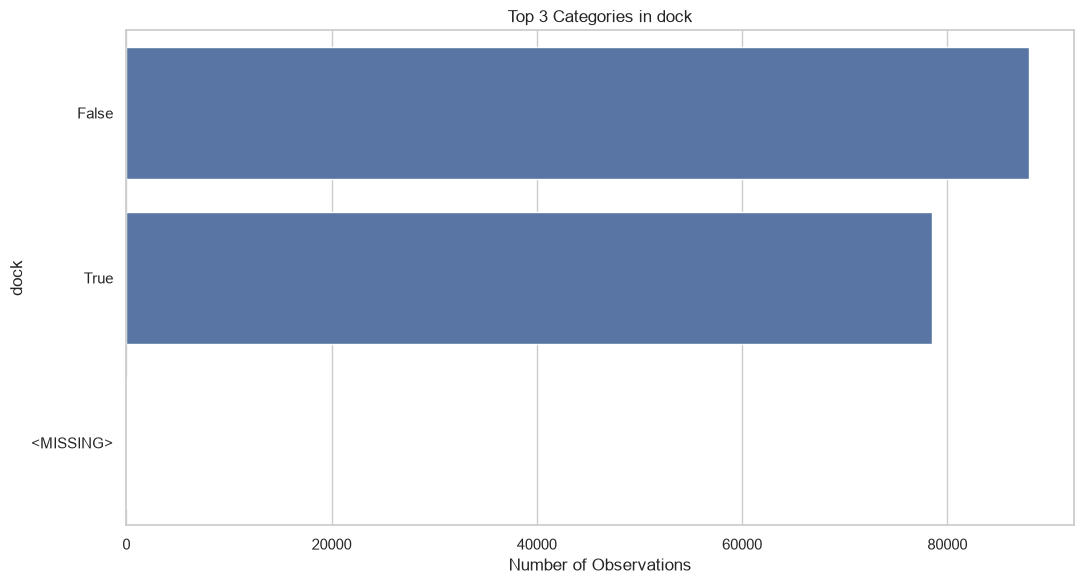

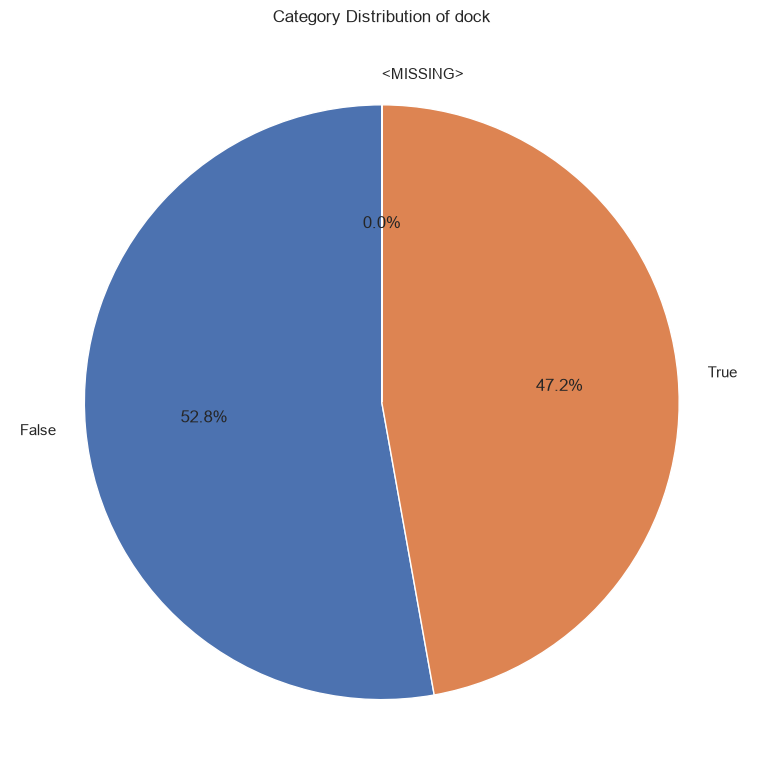


OVERALL CATEGORICAL VARIABLES SUMMARY


,Unique Categories,Most Frequent Category,Most Frequent Count,Most Frequent Percentage (%),Top 10 Coverage (%),Categories for 90% Coverage,Rare Categories,Observations in Rare Categories,Rare Observations (%)
Variable,,,,,,,,,
label,14618,SHANGHAI,3260,1.96,8.20,4507,11111,21227,12.75
sublabel,31151,<MISSING>,6284,3.77,14.19,14503,27786,36894,22.16
label_source,6,anchorage_overrides,126333,75.88,100.00,3,0,0,0.00
iso3,180,CHN,54385,32.67,60.79,43,14,34,0.02
dock,3,False,87939,52.82,100.00,2,0,0,0.00


In [14]:
# ============================================================
# Section 5.2 - Univariate Analysis of Categorical Variables
# ============================================================

categorical_columns = [
    "label",
    "sublabel",
    "label_source",
    "iso3",
    "dock"
]

TOP_K = 10
COVERAGE_TARGET = 90.0
RARE_MAX_COUNT = 5

# Store full result tables for later inspection
categorical_frequency_tables = {}
categorical_coverage_tables = {}
categorical_rare_tables = {}
categorical_summary_rows = []

for column in categorical_columns:

    print("\n" + "=" * 90)
    print(f"CATEGORICAL VARIABLE: {column.upper()}")
    print("=" * 90)

    # Replace missing values with a visible category for analysis
    analyzed_series = ocean_data[column].astype("object").where(
        ocean_data[column].notna(),
        "<MISSING>"
    )

    total_rows = len(analyzed_series)

    # --------------------------------------------------------
    # Frequency table
    # --------------------------------------------------------

    counts = analyzed_series.value_counts(dropna=False)

    frequency_table = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": counts / total_rows * 100
    })

    frequency_table["Cumulative Percentage (%)"] = (
        frequency_table["Percentage (%)"].cumsum()
    )

    categorical_frequency_tables[column] = frequency_table.copy()

    print("\nFREQUENCY TABLE - TOP 20 CATEGORIES")

    display(
        frequency_table.head(20).round({
            "Percentage (%)": 4,
            "Cumulative Percentage (%)": 4
        })
    )

    # --------------------------------------------------------
    # Most frequent category
    # --------------------------------------------------------

    most_frequent_value = frequency_table.index[0]
    most_frequent_count = int(
        frequency_table.iloc[0]["Count"]
    )
    most_frequent_percentage = float(
        frequency_table.iloc[0]["Percentage (%)"]
    )

    print("\nMOST FREQUENT CATEGORY")
    print(f"Value       : {most_frequent_value}")
    print(f"Frequency   : {most_frequent_count:,}")
    print(f"Percentage  : {most_frequent_percentage:.4f}%")

    # --------------------------------------------------------
    # Top-K categories
    # --------------------------------------------------------

    actual_top_k = min(TOP_K, len(frequency_table))
    top_k_table = frequency_table.head(actual_top_k).copy()

    top_k_percentage = top_k_table["Percentage (%)"].sum()

    print(f"\nTOP {actual_top_k} CATEGORIES")

    display(
        top_k_table.round({
            "Percentage (%)": 4,
            "Cumulative Percentage (%)": 4
        })
    )

    print(
        f"The top {actual_top_k} categories represent "
        f"{top_k_percentage:.4f}% of the dataset."
    )

    # --------------------------------------------------------
    # Minimum number of categories required for target coverage
    # --------------------------------------------------------

    target_mask = (
        frequency_table["Cumulative Percentage (%)"]
        >= COVERAGE_TARGET
    )

    if target_mask.any():
        number_for_target = int(np.argmax(target_mask.to_numpy()) + 1)
    else:
        # Defensive fallback for possible floating-point behavior
        number_for_target = len(frequency_table)

    coverage_table = frequency_table.iloc[:number_for_target].copy()
    achieved_coverage = coverage_table["Percentage (%)"].sum()

    categorical_coverage_tables[column] = coverage_table.copy()

    print(
        f"\nMINIMUM NUMBER OF CATEGORIES REQUIRED TO REPRESENT "
        f"AT LEAST {COVERAGE_TARGET:.0f}% OF THE DATA"
    )

    print(f"Number of categories : {number_for_target:,}")
    print(f"Coverage achieved    : {achieved_coverage:.4f}%")

    if number_for_target <= 30:
        print("\nCategories included in the coverage set:")

        display(
            coverage_table.round({
                "Percentage (%)": 4,
                "Cumulative Percentage (%)": 4
            })
        )

    else:
        print(
            "\nThe complete coverage set is large. "
            "Its first 20 and last 10 categories are displayed below."
        )

        print("\nFirst 20 categories in the coverage set:")

        display(
            coverage_table.head(20).round({
                "Percentage (%)": 4,
                "Cumulative Percentage (%)": 4
            })
        )

        print("\nLast 10 categories required to reach the target:")

        display(
            coverage_table.tail(10).round({
                "Percentage (%)": 4,
                "Cumulative Percentage (%)": 4
            })
        )

        print(
            f"\nThe complete list is stored in "
            f"categorical_coverage_tables['{column}']."
        )

    # --------------------------------------------------------
    # Rare categories
    # --------------------------------------------------------

    rare_table = frequency_table[
        frequency_table["Count"] <= RARE_MAX_COUNT
    ].copy()

    categorical_rare_tables[column] = rare_table.copy()

    rare_category_count = len(rare_table)
    rare_observation_count = int(rare_table["Count"].sum())
    rare_observation_percentage = (
        rare_observation_count / total_rows * 100
    )

    print(
        f"\nRARE CATEGORIES "
        f"(DEFINED AS {RARE_MAX_COUNT} OR FEWER OBSERVATIONS)"
    )

    print(
        f"Number of rare categories       : "
        f"{rare_category_count:,}"
    )

    print(
        f"Observations in rare categories : "
        f"{rare_observation_count:,}"
    )

    print(
        f"Dataset percentage represented  : "
        f"{rare_observation_percentage:.4f}%"
    )

    if rare_category_count > 0:
        print("\nExamples of rare categories:")

        display(
            rare_table.head(20).round({
                "Percentage (%)": 4,
                "Cumulative Percentage (%)": 4
            })
        )
    else:
        print("No rare categories were detected using this definition.")

    # --------------------------------------------------------
    # Summary row
    # --------------------------------------------------------

    categorical_summary_rows.append({
        "Variable": column,
        "Unique Categories": len(frequency_table),
        "Most Frequent Category": str(most_frequent_value),
        "Most Frequent Count": most_frequent_count,
        "Most Frequent Percentage (%)": most_frequent_percentage,
        f"Top {TOP_K} Coverage (%)": top_k_percentage,
        f"Categories for {COVERAGE_TARGET:.0f}% Coverage": number_for_target,
        "Rare Categories": rare_category_count,
        "Observations in Rare Categories": rare_observation_count,
        "Rare Observations (%)": rare_observation_percentage
    })

    # --------------------------------------------------------
    # Bar chart of Top-K categories
    # --------------------------------------------------------

    plot_table = top_k_table.reset_index()
    category_name_column = plot_table.columns[0]

    plt.figure(figsize=(11, 6))

    sns.barplot(
        data=plot_table,
        x="Count",
        y=category_name_column
    )

    plt.title(f"Top {actual_top_k} Categories in {column}")
    plt.xlabel("Number of Observations")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Pie chart only for low-cardinality variables
    # --------------------------------------------------------

    if len(frequency_table) <= 10:

        plt.figure(figsize=(8, 8))

        plt.pie(
            frequency_table["Count"],
            labels=frequency_table.index.astype(str),
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(f"Category Distribution of {column}")
        plt.tight_layout()
        plt.show()


# ============================================================
# Overall categorical summary
# ============================================================

categorical_summary = pd.DataFrame(
    categorical_summary_rows
).set_index("Variable")

print("\n" + "=" * 100)
print("OVERALL CATEGORICAL VARIABLES SUMMARY")
print("=" * 100)

display(
    categorical_summary.round({
        "Most Frequent Percentage (%)": 4,
        f"Top {TOP_K} Coverage (%)": 4,
        "Rare Observations (%)": 4
    })
)

### Discussion

The categorical variables exhibit very different distribution patterns.

The **label** and **sublabel** variables contain thousands of unique categories. The most frequent values represent only a small fraction of the observations (approximately 2% and 4%, respectively). More than four thousand categories are required to describe 90% of the data, indicating extremely high diversity. This suggests that no single category can adequately represent these variables.

The **iso3** variable is moderately concentrated. China (CHN) accounts for approximately one third of the observations, while the remaining records are distributed across many additional countries. Therefore, although several countries dominate the dataset, substantial geographical diversity still exists.

The **label_source** variable is highly concentrated. More than 75% of all observations originate from the `anchorage_overrides` source, indicating that one collection mechanism dominates the dataset.

The **dock** variable is nearly balanced between True and False, indicating that both dock and non-dock anchorages are well represented.

Overall, central tendency measures alone do not adequately summarize most categorical variables because of their high cardinality and long-tail distributions. Frequency tables and cumulative coverage analysis provide a much more informative description of the dataset.

CORRELATION ANALYSIS

PEARSON CORRELATION


,lat,lon,distance_from_shore_m,drift_radius
lat,1.00,-0.08,-0.12,-0.15
lon,-0.08,1.00,-0.03,0.17
distance_from_shore_m,-0.12,-0.03,1.00,0.28
drift_radius,-0.15,0.17,0.28,1.00



SPEARMAN CORRELATION


,lat,lon,distance_from_shore_m,drift_radius
lat,1.00,-0.14,-0.19,-0.18
lon,-0.14,1.00,0.13,0.17
distance_from_shore_m,-0.19,0.13,1.00,0.55
drift_radius,-0.18,0.17,0.55,1.00



KENDALL CORRELATION


,lat,lon,distance_from_shore_m,drift_radius
lat,1.00,-0.08,-0.14,-0.12
lon,-0.08,1.00,0.09,0.12
distance_from_shore_m,-0.14,0.09,1.00,0.41
drift_radius,-0.12,0.12,0.41,1.00



SUMMARY OF ALL PAIRS


,Variable 1,Variable 2,Pearson,Spearman,Kendall
0,lat,lon,-0.08,-0.14,-0.08
1,lat,distance_from_shore_m,-0.12,-0.19,-0.14
2,lat,drift_radius,-0.15,-0.18,-0.12
3,lon,distance_from_shore_m,-0.03,0.13,0.09
4,lon,drift_radius,0.17,0.17,0.12
5,distance_from_shore_m,drift_radius,0.28,0.55,0.41


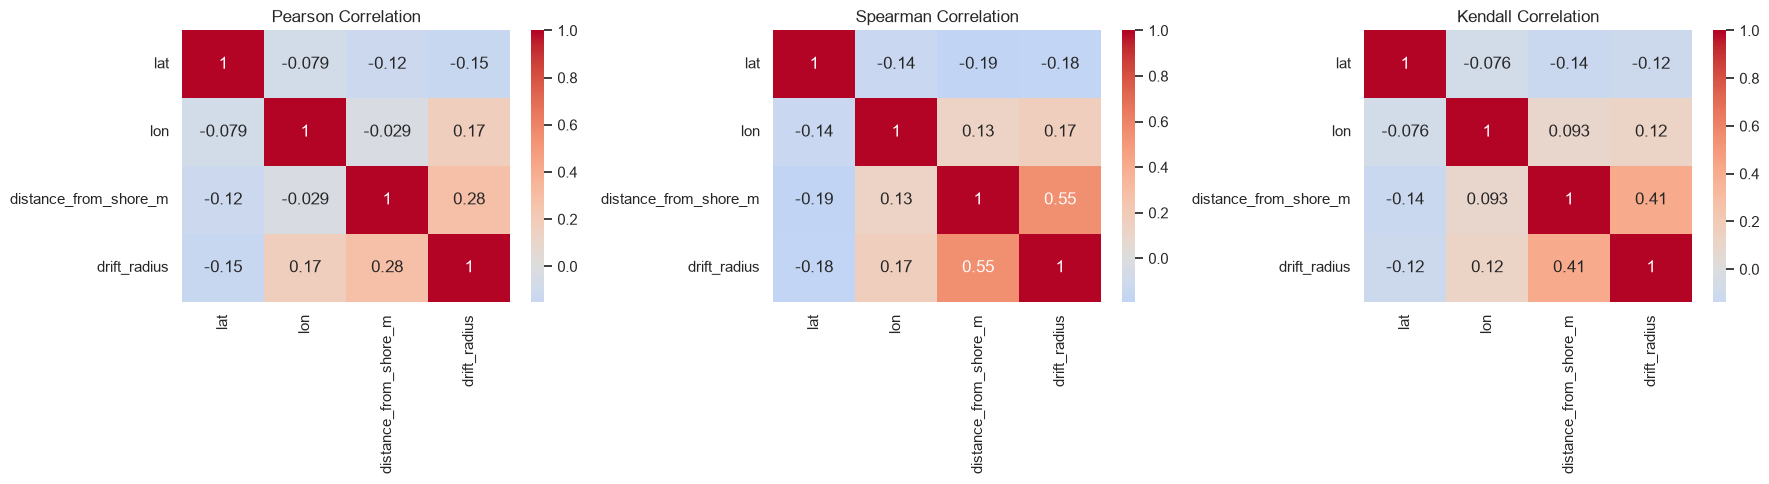

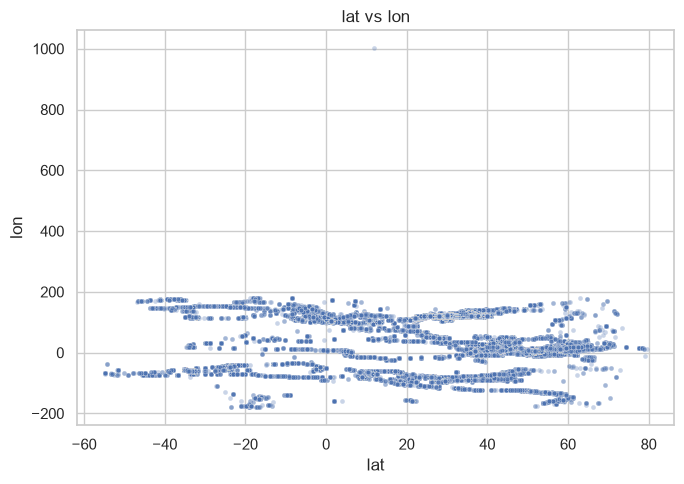

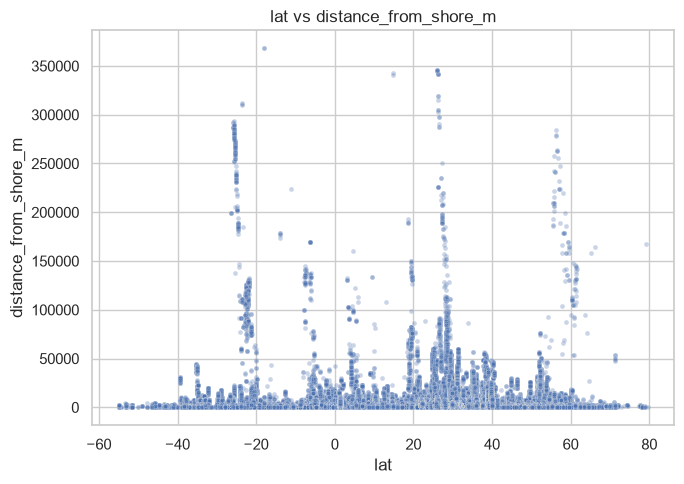

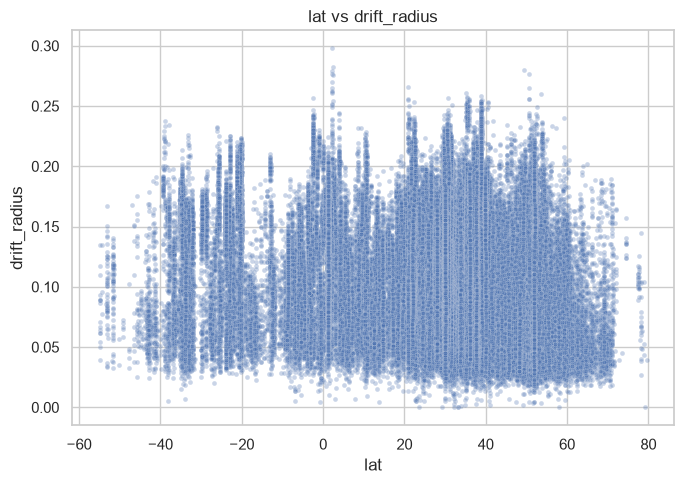

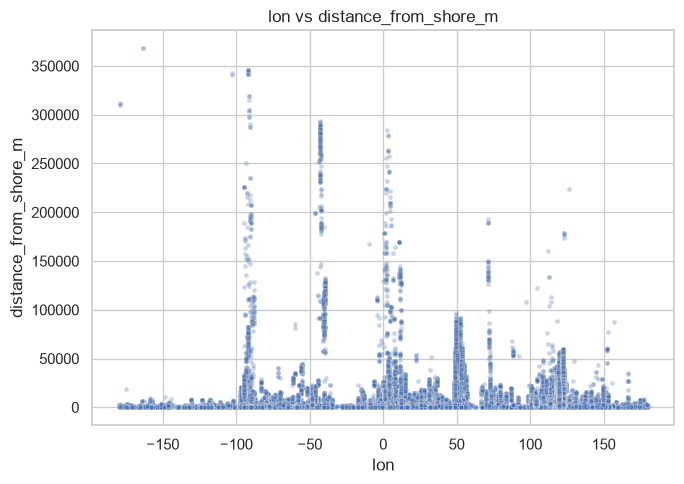

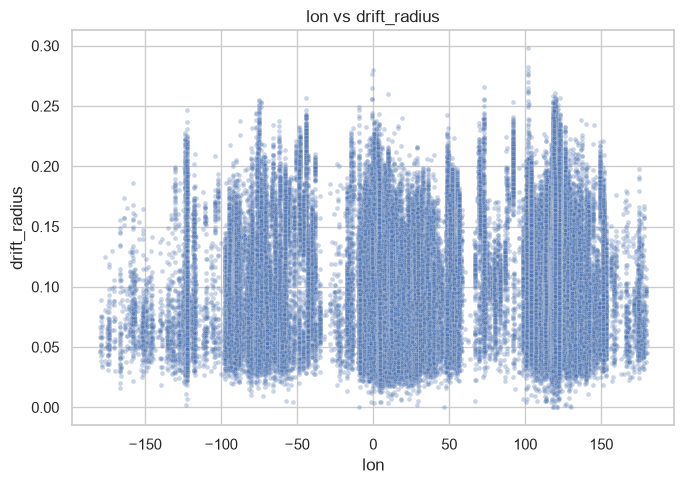

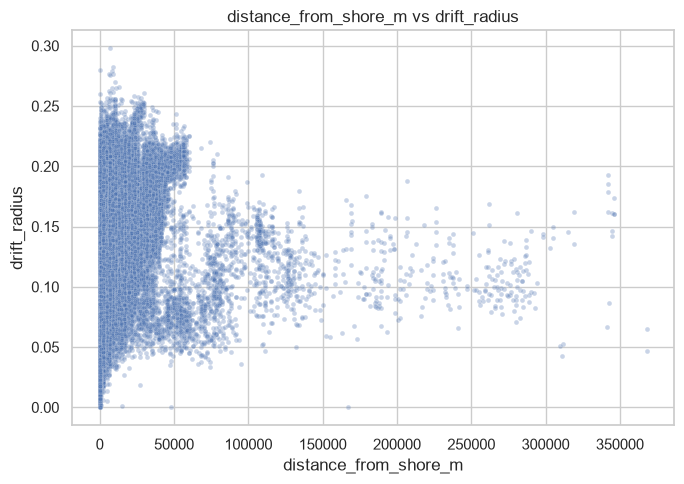

In [15]:
# ============================================================
# Section 6.1 - Numerical vs Numerical Relationships
# ============================================================

numeric_columns = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

numeric_data = ocean_data[numeric_columns].copy()

print("=" * 100)
print("CORRELATION ANALYSIS")
print("=" * 100)

# ----------------------------------------------------
# Pearson
# ----------------------------------------------------

pearson_corr = numeric_data.corr(method="pearson")

print("\nPEARSON CORRELATION")
display(pearson_corr.round(4))

# ----------------------------------------------------
# Spearman
# ----------------------------------------------------

spearman_corr = numeric_data.corr(method="spearman")

print("\nSPEARMAN CORRELATION")
display(spearman_corr.round(4))

# ----------------------------------------------------
# Kendall
# ----------------------------------------------------

kendall_corr = numeric_data.corr(method="kendall")

print("\nKENDALL CORRELATION")
display(kendall_corr.round(4))

# ----------------------------------------------------
# Summary Table
# ----------------------------------------------------

summary_rows = []

for i in range(len(numeric_columns)):
    for j in range(i + 1, len(numeric_columns)):

        c1 = numeric_columns[i]
        c2 = numeric_columns[j]

        summary_rows.append({

            "Variable 1": c1,
            "Variable 2": c2,

            "Pearson":
                pearson_corr.loc[c1, c2],

            "Spearman":
                spearman_corr.loc[c1, c2],

            "Kendall":
                kendall_corr.loc[c1, c2]

        })

correlation_summary = pd.DataFrame(summary_rows)

print("\nSUMMARY OF ALL PAIRS")

display(correlation_summary.round(4))

# ============================================================
# Heatmaps
# ============================================================

fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)

axes[0].set_title("Pearson Correlation")

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)

axes[1].set_title("Spearman Correlation")

sns.heatmap(
    kendall_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[2]
)

axes[2].set_title("Kendall Correlation")

plt.tight_layout()

plt.show()

# ============================================================
# Scatter plots
# ============================================================

from itertools import combinations

pairs = list(combinations(numeric_columns,2))

for x,y in pairs:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=ocean_data,
        x=x,
        y=y,
        alpha=0.30,
        s=12
    )

    plt.title(f"{x} vs {y}")

    plt.tight_layout()

    plt.show()

## Discussion – Section 6.1

### Pearson Correlation
Pearson correlation measures the strength of a **linear relationship** between two numerical variables. It is sensitive to outliers and assumes approximately linear behavior.

### Spearman Correlation
Spearman correlation is based on the **ranking** of observations rather than their actual values. It measures monotonic relationships and is more robust to outliers and skewed distributions.

### Kendall Correlation
Kendall correlation also measures monotonic association using concordant and discordant observation pairs. It is generally more conservative than Spearman and is particularly useful when many tied values exist.

---

### Correlation Matrix Analysis

Most pairs of numerical variables exhibit **weak correlations**, indicating that the variables are largely independent.

The strongest relationship is between **distance_from_shore_m** and **drift_radius**:

- Pearson = **0.28**
- Spearman = **0.55**
- Kendall = **0.41**

This indicates a **positive monotonic relationship**. As the distance from shore increases, the drift radius generally tends to increase, although the relationship is not perfectly linear.

The noticeably higher Spearman coefficient compared to the Pearson coefficient suggests that the relationship is better described as **monotonic rather than linear**.

Latitude and longitude show only weak correlations with the remaining numerical variables:

- Latitude vs Longitude – weak negative correlation.
- Latitude vs Distance from Shore – weak negative correlation.
- Latitude vs Drift Radius – weak negative correlation.
- Longitude vs Distance from Shore – almost no correlation.
- Longitude vs Drift Radius – weak positive correlation.

Overall, these coefficients are close to zero, indicating only limited dependency between the variables.

---

### Scatter Plot Interpretation

The scatter plots support the numerical results.

- Most variable pairs appear as widely scattered point clouds with no clear linear trend.
- The relationship between **distance_from_shore_m** and **drift_radius** shows an overall increasing tendency, although the observations remain highly dispersed.
- Several variables contain dense clusters and extreme observations, reducing the Pearson correlation coefficient.
- Geographic variables (latitude and longitude) form spatial clusters rather than continuous linear relationships, explaining their relatively weak correlations.
- The latitude versus longitude scatter plot also reveals a single extreme outlier (longitude = 1001), which was previously identified during the suspicious values analysis. This record represents a data quality issue rather than a genuine geographical observation.

---

### Conclusions

- Most numerical variables exhibit **weak correlations**.
- The strongest association is between **distance_from_shore_m** and **drift_radius**.
- Spearman and Kendall coefficients are noticeably higher than Pearson, indicating that the relationship is primarily monotonic rather than strictly linear.
- The scatter plots support the correlation analysis and show no evidence of strong linear dependence among most numerical variables.
- The detected geographical outlier should be treated as a data quality issue rather than a meaningful observation.

CATEGORICAL VARIABLE PREPARATION


,Original Unique Values,Analyzed Unique Values,Grouping Applied
label_grouped,14618,21,Top 20 + <OTHER>
sublabel_grouped,31151,21,Top 20 + <OTHER>
label_source,6,6,No
iso3,180,180,No
dock,3,3,No



CATEGORICAL PAIR: LABEL_GROUPED VS SUBLABEL_GROUPED

CONTINGENCY TABLE


sublabel_grouped,<MISSING>,<OTHER>,DALIAN,FUZHOU,HOUSTON,NANTONG,NINGBO,QINGDAO,QINHUANGDAO,RIZHAO,ROTTERDAM,SHANGHAI,SINGAPORE,TAIZHOU,TANGSHAN,TIANJIN,WEIHAI,WENZHOU,YANTAI,ZHOUSHAN,ZHUHAI
label_grouped,,,,,,,,,,,,,,,,,,,,,
<OTHER>,6284,127160,359,920,157,953,517,119,1,986,203,344,726,691,9,7,869,882,932,2152,911
ANTWERP,0,700,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BAYUQUAN,0,634,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CAOFEIDIAN,0,22,0,0,0,0,0,0,0,0,0,0,0,0,814,0,0,0,0,0,0
DALIAN,0,5,743,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
FUJAIRAH,0,789,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
GUANGZHOU,0,817,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,455
HOUSTON,0,168,0,0,697,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
HUANGHUA,0,980,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



STATISTICAL ASSOCIATION
Chi-square statistic : 1,320,987.1353
Degrees of freedom   : 400
P-value              : 0
Cramér's V           : 0.6298
Association strength : Strong
Expected cells below 5: 122 of 441 (27.66%)
Caution: More than 20% of expected cell frequencies are below 5. The Chi-square approximation should be interpreted carefully for this pair.

CATEGORICAL PAIR: LABEL_GROUPED VS LABEL_SOURCE

CONTINGENCY TABLE


...

dock,<MISSING>,False,True
iso3,,,
AGO,0,391,50
AIA,0,6,17
ALA,0,0,14
ALB,0,21,12
ARE,0,2791,369
ARG,0,342,465
ATG,0,18,87
AUS,0,1638,1414
AUT,0,0,135


Complete table shape: 180 rows × 3 columns

STATISTICAL ASSOCIATION
Chi-square statistic : 40,508.9482
Degrees of freedom   : 358
P-value              : 0
Cramér's V           : 0.3473
Association strength : Moderate
Expected cells below 5: 225 of 540 (41.67%)
Caution: More than 20% of expected cell frequencies are below 5. The Chi-square approximation should be interpreted carefully for this pair.

OVERALL CATEGORICAL RELATIONSHIP SUMMARY


,Variable 1,Variable 2,Table Rows,Table Columns,Chi-Square,Degrees of Freedom,P-Value,Cramer's V,Association Strength,Cells with Expected Frequency < 5,Cells with Expected Frequency < 5 (%)
0,label_grouped,sublabel_grouped,21,21,"1,320,987.14",400,0.00,0.63,Strong,122,27.66
1,label_grouped,iso3,21,180,"525,815.85",3580,0.00,0.40,Moderate,2954,78.15
2,iso3,dock,180,3,"40,508.95",358,0.00,0.35,Moderate,225,41.67
3,sublabel_grouped,iso3,21,180,"382,298.53",3580,0.00,0.34,Moderate,2780,73.54
4,label_source,iso3,6,180,"81,512.96",895,0.00,0.31,Moderate,583,53.98
5,label_source,dock,6,3,"18,965.96",10,0.00,0.24,Moderate,7,38.89
6,label_grouped,dock,21,3,"10,365.03",40,0.00,0.18,Weak,20,31.75
7,sublabel_grouped,dock,21,3,"9,463.55",40,0.00,0.17,Weak,20,31.75
8,sublabel_grouped,label_source,21,6,"15,131.04",100,0.00,0.13,Weak,40,31.75
9,label_grouped,label_source,21,6,"13,152.62",100,0.00,0.13,Weak,40,31.75



CRAMÉR'S V ASSOCIATION MATRIX


,label_grouped,sublabel_grouped,label_source,iso3,dock
label_grouped,1.00,0.63,0.13,0.40,0.18
sublabel_grouped,0.63,1.00,0.13,0.34,0.17
label_source,0.13,0.13,1.00,0.31,0.24
iso3,0.40,0.34,0.31,1.00,0.35
dock,0.18,0.17,0.24,0.35,1.00


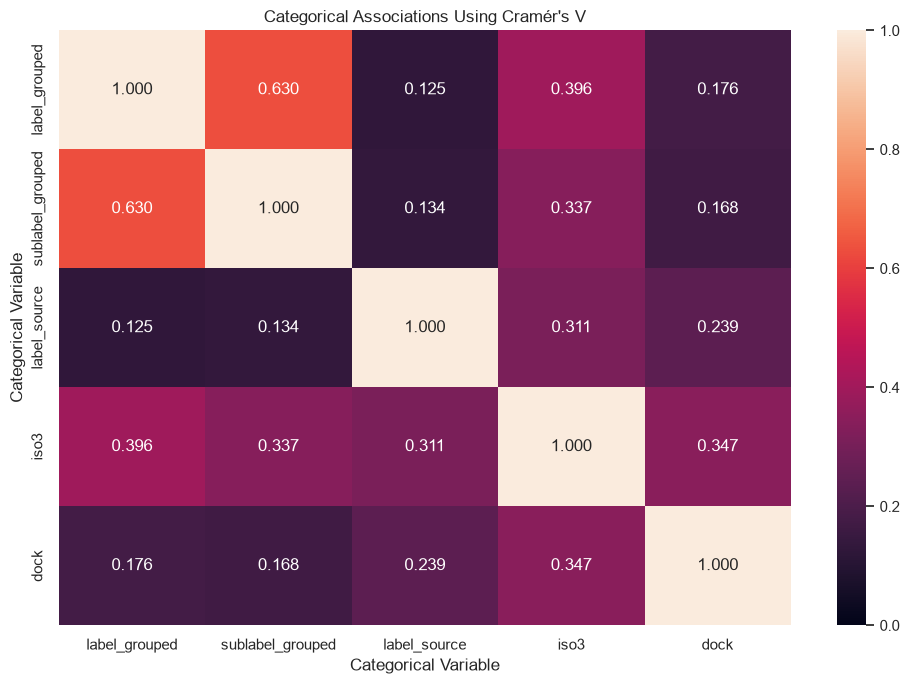

BINNED NUMERICAL VARIABLES

lat_bin
------------------------------------------------------------


,Count
lat_bin,
"(43.424, 79.559]",33297
"(-54.940999999999995, 21.292]",33297
"(21.292, 29.94]",33296
"(35.267, 43.424]",33296
"(29.94, 35.267]",33296



lon_bin
------------------------------------------------------------


,Count
lon_bin,
"(121.096, 1001.0]",33297
"(-179.939, 1.267]",33297
"(1.267, 30.311]",33296
"(30.311, 113.683]",33296
"(113.683, 121.096]",33296



distance_from_shore_m_bin
------------------------------------------------------------


,Count
distance_from_shore_m_bin,
"(-0.001, 2000.0]",103082
"(2000.0, 8000.0]",31859
"(8000.0, 368000.0]",31516
NaN,25



drift_radius_bin
------------------------------------------------------------


,Count
drift_radius_bin,
"(-0.0009999999991480001, 0.0642]",33266
"(0.144, 0.298]",33266
"(0.0642, 0.0871]",33266
"(0.111, 0.144]",33266
"(0.0871, 0.111]",33265
NaN,153



BINNED NUMERICAL VS CATEGORICAL SUMMARY


,Numeric Variable,Categorical Variable,Chi-Square,Degrees of Freedom,P-Value,Cramer's V,Association
0,lon,iso3,"435,240.39",716,0.00,0.81,Strong
1,lat,iso3,"371,230.78",716,0.00,0.75,Strong
2,drift_radius,dock,"46,613.09",4,0.00,0.53,Relatively strong
3,distance_from_shore_m,dock,"86,071.79",4,0.00,0.51,Relatively strong
4,lat,sublabel_grouped,"111,553.29",80,0.00,0.41,Relatively strong
5,distance_from_shore_m,iso3,"52,779.36",358,0.00,0.40,Moderate
6,lon,sublabel_grouped,"101,484.81",80,0.00,0.39,Moderate
7,lon,label_grouped,"80,063.06",80,0.00,0.35,Moderate
8,lat,label_grouped,"77,466.46",80,0.00,0.34,Moderate
9,distance_from_shore_m,label_grouped,"33,846.23",40,0.00,0.32,Moderate


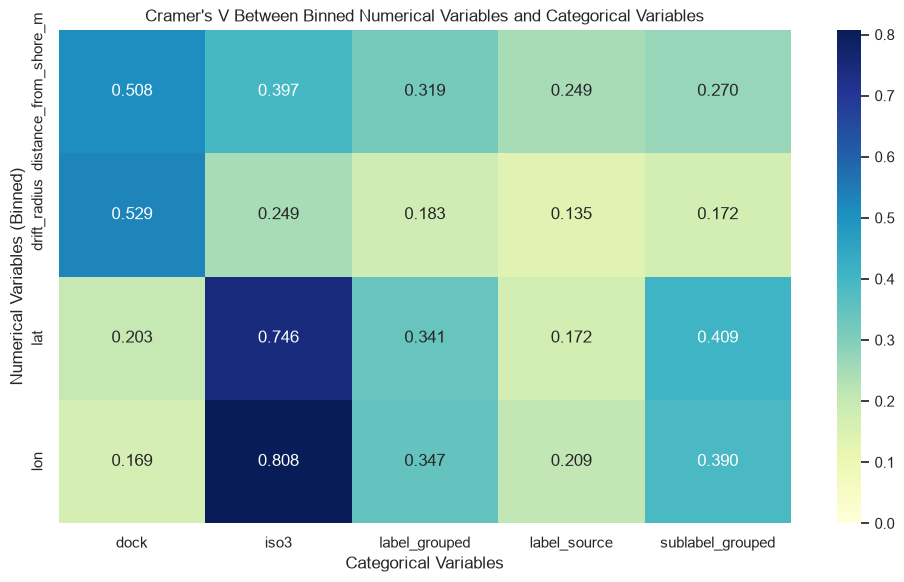


TOP 10 STRONGEST NUMERICAL-CATEGORICAL RELATIONSHIPS


,Numeric Variable,Categorical Variable,Chi-Square,Degrees of Freedom,P-Value,Cramer's V,Association
0,lon,iso3,"435,240.39",716,0.00,0.81,Strong
1,lat,iso3,"371,230.78",716,0.00,0.75,Strong
2,drift_radius,dock,"46,613.09",4,0.00,0.53,Relatively strong
3,distance_from_shore_m,dock,"86,071.79",4,0.00,0.51,Relatively strong
4,lat,sublabel_grouped,"111,553.29",80,0.00,0.41,Relatively strong
5,distance_from_shore_m,iso3,"52,779.36",358,0.00,0.40,Moderate
6,lon,sublabel_grouped,"101,484.81",80,0.00,0.39,Moderate
7,lon,label_grouped,"80,063.06",80,0.00,0.35,Moderate
8,lat,label_grouped,"77,466.46",80,0.00,0.34,Moderate
9,distance_from_shore_m,label_grouped,"33,846.23",40,0.00,0.32,Moderate


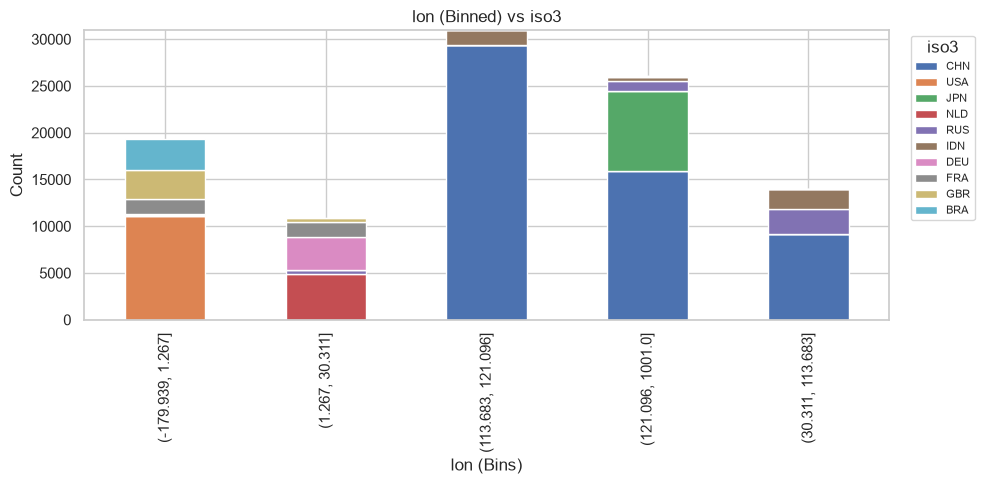

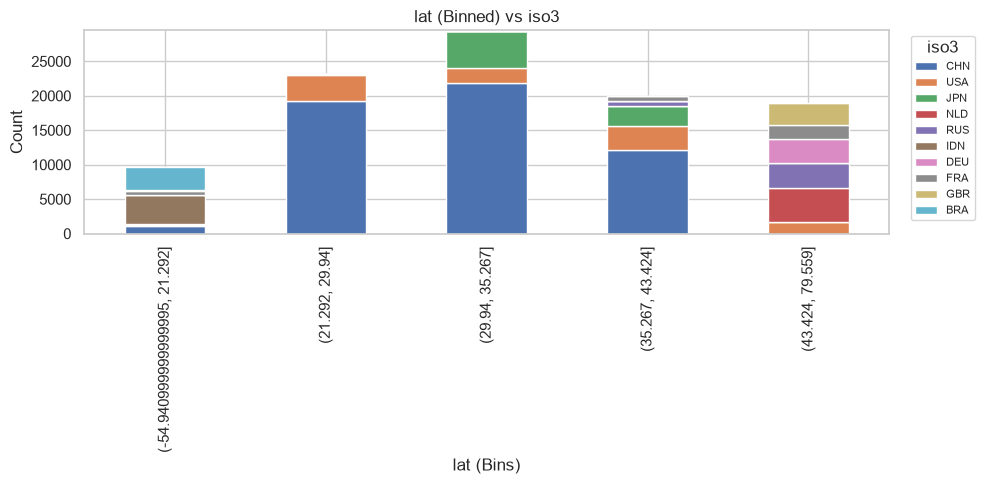

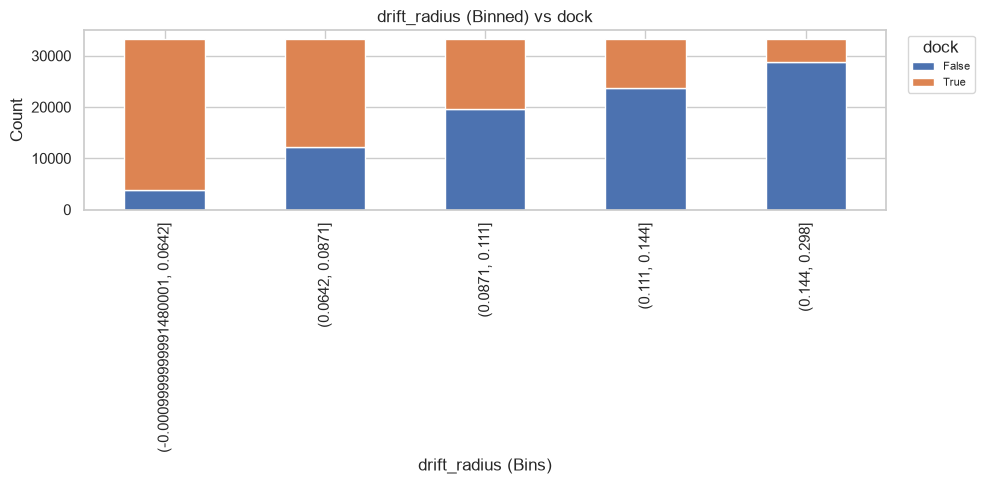

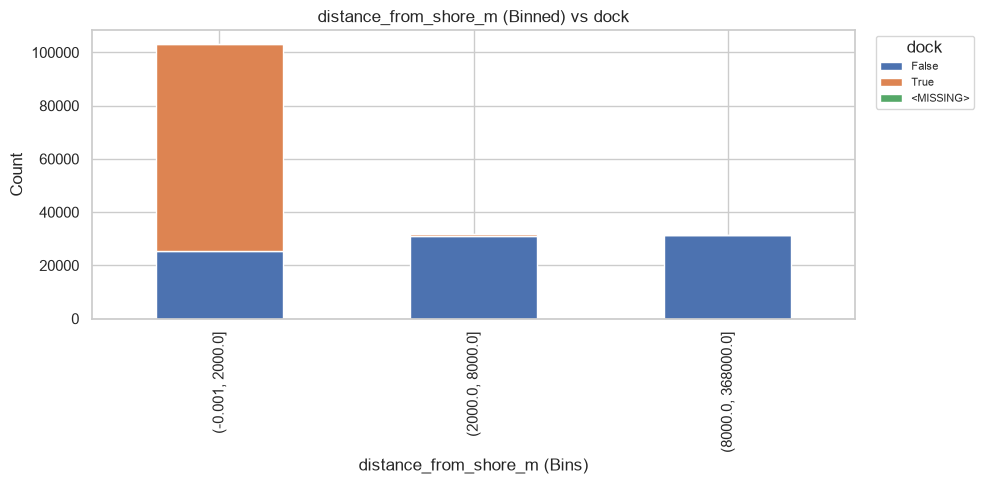


OVERALL RELATIONSHIP SUMMARY


,Variable A,Variable B,Cramer's V,Relationship
10,lon,iso3,0.81,Strong
11,lat,iso3,0.75,Strong
0,label_grouped,sublabel_grouped,0.63,Strong
12,drift_radius,dock,0.53,Relatively strong
13,distance_from_shore_m,dock,0.51,Relatively strong
14,lat,sublabel_grouped,0.41,Relatively strong
15,distance_from_shore_m,iso3,0.40,Moderate
1,label_grouped,iso3,0.40,Moderate
16,lon,sublabel_grouped,0.39,Moderate
2,iso3,dock,0.35,Moderate


In [18]:
# ============================================================
# Section 6.2 - Categorical Relationships
# Part 1: Categorical vs Categorical Analysis
# ============================================================

# Analysis settings
TOP_N_HIGH_CARDINALITY = 20
MIN_EXPECTED_FREQUENCY = 5

# Store outputs for later use
categorical_pair_results = []
contingency_tables = {}


# ------------------------------------------------------------
# Helper function: prepare categorical variables
# ------------------------------------------------------------

def prepare_categorical_series(
    series,
    top_n=None,
    missing_label="<MISSING>",
    other_label="<OTHER>"
):
    """
    Convert a variable to a categorical representation.

    Missing values are represented explicitly. For high-cardinality
    variables, only the most frequent categories are retained and all
    remaining values are grouped under <OTHER>.
    """
    prepared = series.astype("object").where(
        series.notna(),
        missing_label
    )

    if top_n is not None and prepared.nunique(dropna=False) > top_n:
        most_common_values = prepared.value_counts(
            dropna=False
        ).head(top_n).index

        prepared = prepared.where(
            prepared.isin(most_common_values),
            other_label
        )

    return prepared.astype(str)


# ------------------------------------------------------------
# Helper function: bias-corrected Cramér's V
# ------------------------------------------------------------

def calculate_cramers_v(contingency_table):
    """
    Calculate bias-corrected Cramér's V from a contingency table.

    Cramér's V ranges from 0 to 1:
    0 indicates no association.
    Values closer to 1 indicate a stronger association.
    """
    chi_square, _, _, _ = stats.chi2_contingency(
        contingency_table,
        correction=False
    )

    sample_size = contingency_table.to_numpy().sum()

    if sample_size <= 1:
        return np.nan

    phi_squared = chi_square / sample_size
    rows, columns = contingency_table.shape

    corrected_phi_squared = max(
        0,
        phi_squared
        - ((columns - 1) * (rows - 1)) / (sample_size - 1)
    )

    corrected_rows = rows - ((rows - 1) ** 2) / (sample_size - 1)
    corrected_columns = (
        columns - ((columns - 1) ** 2) / (sample_size - 1)
    )

    denominator = min(
        corrected_columns - 1,
        corrected_rows - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(corrected_phi_squared / denominator)


# ------------------------------------------------------------
# Helper function: interpret Cramér's V
# ------------------------------------------------------------

def interpret_cramers_v(value):
    """
    Provide a descriptive interpretation of Cramér's V.
    """
    if pd.isna(value):
        return "Not available"
    if value < 0.10:
        return "Negligible"
    if value < 0.20:
        return "Weak"
    if value < 0.40:
        return "Moderate"
    if value < 0.60:
        return "Relatively strong"
    return "Strong"


# ------------------------------------------------------------
# Prepare categorical variables
# ------------------------------------------------------------

categorical_analysis_data = pd.DataFrame(index=ocean_data.index)

# High-cardinality variables are grouped to prevent enormous,
# highly sparse contingency tables.
categorical_analysis_data["label_grouped"] = (
    prepare_categorical_series(
        ocean_data["label"],
        top_n=TOP_N_HIGH_CARDINALITY
    )
)

categorical_analysis_data["sublabel_grouped"] = (
    prepare_categorical_series(
        ocean_data["sublabel"],
        top_n=TOP_N_HIGH_CARDINALITY
    )
)

# Lower-cardinality variables are retained without grouping.
categorical_analysis_data["label_source"] = (
    prepare_categorical_series(ocean_data["label_source"])
)

categorical_analysis_data["iso3"] = (
    prepare_categorical_series(ocean_data["iso3"])
)

categorical_analysis_data["dock"] = (
    prepare_categorical_series(ocean_data["dock"])
)

categorical_variables = categorical_analysis_data.columns.tolist()


print("=" * 100)
print("CATEGORICAL VARIABLE PREPARATION")
print("=" * 100)

preparation_summary = pd.DataFrame({
    "Original Unique Values": [
        ocean_data["label"].nunique(dropna=False),
        ocean_data["sublabel"].nunique(dropna=False),
        ocean_data["label_source"].nunique(dropna=False),
        ocean_data["iso3"].nunique(dropna=False),
        ocean_data["dock"].nunique(dropna=False)
    ],
    "Analyzed Unique Values": [
        categorical_analysis_data[column].nunique(dropna=False)
        for column in categorical_variables
    ],
    "Grouping Applied": [
        "Top 20 + <OTHER>",
        "Top 20 + <OTHER>",
        "No",
        "No",
        "No"
    ]
}, index=categorical_variables)

display(preparation_summary)


# ------------------------------------------------------------
# Analyze every categorical-variable pair
# ------------------------------------------------------------

from itertools import combinations

categorical_pairs = list(combinations(categorical_variables, 2))

for first_variable, second_variable in categorical_pairs:

    print("\n" + "=" * 100)
    print(
        f"CATEGORICAL PAIR: "
        f"{first_variable.upper()} VS {second_variable.upper()}"
    )
    print("=" * 100)

    contingency_table = pd.crosstab(
        categorical_analysis_data[first_variable],
        categorical_analysis_data[second_variable],
        dropna=False
    )

    contingency_tables[
        (first_variable, second_variable)
    ] = contingency_table.copy()

    # Chi-square test of independence
    chi_square, p_value, degrees_of_freedom, expected_frequencies = (
        stats.chi2_contingency(
            contingency_table,
            correction=False
        )
    )

    cramers_v = calculate_cramers_v(contingency_table)

    expected_frequencies = np.asarray(expected_frequencies)

    cells_below_five = int(
        (expected_frequencies < MIN_EXPECTED_FREQUENCY).sum()
    )

    total_cells = expected_frequencies.size

    percentage_cells_below_five = (
        cells_below_five / total_cells * 100
        if total_cells > 0
        else np.nan
    )

    categorical_pair_results.append({
        "Variable 1": first_variable,
        "Variable 2": second_variable,
        "Table Rows": contingency_table.shape[0],
        "Table Columns": contingency_table.shape[1],
        "Chi-Square": chi_square,
        "Degrees of Freedom": degrees_of_freedom,
        "P-Value": p_value,
        "Cramer's V": cramers_v,
        "Association Strength": interpret_cramers_v(cramers_v),
        "Cells with Expected Frequency < 5": cells_below_five,
        "Cells with Expected Frequency < 5 (%)":
            percentage_cells_below_five
    })

    print("\nCONTINGENCY TABLE")

    # Display the complete table only when it remains readable.
    if (
        contingency_table.shape[0] <= 25
        and contingency_table.shape[1] <= 25
    ):
        display(contingency_table)
    else:
        print(
            "The complete table is too large for a readable display. "
            "A limited preview is shown below."
        )

        display(
            contingency_table.iloc[:15, :15]
        )

        print(
            f"Complete table shape: "
            f"{contingency_table.shape[0]} rows × "
            f"{contingency_table.shape[1]} columns"
        )

    print("\nSTATISTICAL ASSOCIATION")

    print(f"Chi-square statistic : {chi_square:,.4f}")
    print(f"Degrees of freedom   : {degrees_of_freedom:,}")
    print(f"P-value              : {p_value:.6g}")
    print(f"Cramér's V           : {cramers_v:.4f}")
    print(
        f"Association strength : "
        f"{interpret_cramers_v(cramers_v)}"
    )

    print(
        f"Expected cells below {MIN_EXPECTED_FREQUENCY}: "
        f"{cells_below_five:,} of {total_cells:,} "
        f"({percentage_cells_below_five:.2f}%)"
    )

    if percentage_cells_below_five > 20:
        print(
            "Caution: More than 20% of expected cell frequencies "
            "are below 5. The Chi-square approximation should be "
            "interpreted carefully for this pair."
        )


# ------------------------------------------------------------
# Overall categorical-pair summary
# ------------------------------------------------------------

categorical_relationship_summary = pd.DataFrame(
    categorical_pair_results
)

categorical_relationship_summary = (
    categorical_relationship_summary
    .sort_values("Cramer's V", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 110)
print("OVERALL CATEGORICAL RELATIONSHIP SUMMARY")
print("=" * 110)

display(
    categorical_relationship_summary.round({
        "Chi-Square": 3,
        "P-Value": 6,
        "Cramer's V": 4,
        "Cells with Expected Frequency < 5 (%)": 2
    })
)


# ------------------------------------------------------------
# Cramér's V association matrix
# ------------------------------------------------------------

cramers_v_matrix = pd.DataFrame(
    np.eye(len(categorical_variables)),
    index=categorical_variables,
    columns=categorical_variables
)

for result in categorical_pair_results:
    first_variable = result["Variable 1"]
    second_variable = result["Variable 2"]
    association_value = result["Cramer's V"]

    cramers_v_matrix.loc[
        first_variable,
        second_variable
    ] = association_value

    cramers_v_matrix.loc[
        second_variable,
        first_variable
    ] = association_value

print("\n" + "=" * 100)
print("CRAMÉR'S V ASSOCIATION MATRIX")
print("=" * 100)

display(cramers_v_matrix.round(4))


plt.figure(figsize=(10, 7))

sns.heatmap(
    cramers_v_matrix,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1
)

plt.title("Categorical Associations Using Cramér's V")
plt.xlabel("Categorical Variable")
plt.ylabel("Categorical Variable")
plt.tight_layout()
plt.show()

binned_data = pd.DataFrame(index=ocean_data.index)

numerical_columns = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

for column in numerical_columns:

    valid_values = ocean_data[column]

    try:
        binned_data[column + "_bin"] = pd.qcut(
            valid_values,
            q=5,
            duplicates="drop"
        ).astype(str)

    except ValueError:

        binned_data[column + "_bin"] = pd.cut(
            valid_values,
            bins=5
        ).astype(str)


print("=" * 100)
print("BINNED NUMERICAL VARIABLES")
print("=" * 100)

for column in binned_data.columns:

    print(f"\n{column}")
    print("-" * 60)

    display(
        binned_data[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


# ------------------------------------------------------------
# Numerical (binned) vs categorical relationships
# ------------------------------------------------------------

mixed_relationship_results = []

for numeric_bin in binned_data.columns:

    for categorical_variable in categorical_variables:

        contingency = pd.crosstab(
            binned_data[numeric_bin],
            categorical_analysis_data[categorical_variable]
        )

        chi2, p, dof, expected = stats.chi2_contingency(
            contingency,
            correction=False
        )

        cramers = calculate_cramers_v(contingency)

        mixed_relationship_results.append({

            "Numeric Variable":
                numeric_bin.replace("_bin", ""),

            "Categorical Variable":
                categorical_variable,

            "Chi-Square":
                chi2,

            "Degrees of Freedom":
                dof,

            "P-Value":
                p,

            "Cramer's V":
                cramers,

            "Association":
                interpret_cramers_v(cramers)

        })


mixed_summary = pd.DataFrame(
    mixed_relationship_results
)

mixed_summary = mixed_summary.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("BINNED NUMERICAL VS CATEGORICAL SUMMARY")
print("=" * 100)

display(
    mixed_summary.round({
        "Chi-Square":3,
        "P-Value":6,
        "Cramer's V":4
    })
)


# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

heatmap_table = mixed_summary.pivot(
    index="Numeric Variable",
    columns="Categorical Variable",
    values="Cramer's V"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_table,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=max(0.4, heatmap_table.max().max())
)

plt.title("Cramer's V Between Binned Numerical Variables and Categorical Variables")
plt.xlabel("Categorical Variables")
plt.ylabel("Numerical Variables (Binned)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Strongest relationships
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TOP 10 STRONGEST NUMERICAL-CATEGORICAL RELATIONSHIPS")
print("=" * 100)

display(
    mixed_summary.head(10).round(4)
)


# ------------------------------------------------------------
# Visualize strongest relationships
# ------------------------------------------------------------

# ------------------------------------------------------------
# Visualize strongest relationships
# ------------------------------------------------------------

top_relationships = mixed_summary.head(4)

for _, row in top_relationships.iterrows():

    numeric = row["Numeric Variable"]
    categorical = row["Categorical Variable"]

    contingency = pd.crosstab(
        binned_data[numeric + "_bin"],
        categorical_analysis_data[categorical]
    )

    # Keep only the 10 most frequent categories
    top_categories = contingency.sum(axis=0).nlargest(10).index
    contingency = contingency[top_categories]

    plt.figure(figsize=(10,5))

    contingency.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca()
    )

    plt.title(f"{numeric} (Binned) vs {categorical}")

    plt.xlabel(f"{numeric} (Bins)")
    plt.ylabel("Count")

    plt.legend(
        title=categorical,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Overall conclusions table
# ------------------------------------------------------------

overall_summary = pd.concat(

    [

        categorical_relationship_summary[
            [
                "Variable 1",
                "Variable 2",
                "Cramer's V",
                "Association Strength"
            ]
        ].rename(

            columns={
                "Variable 1":"Variable A",
                "Variable 2":"Variable B",
                "Association Strength":"Relationship"
            }

        ),

        mixed_summary[
            [
                "Numeric Variable",
                "Categorical Variable",
                "Cramer's V",
                "Association"
            ]
        ].rename(

            columns={
                "Numeric Variable":"Variable A",
                "Categorical Variable":"Variable B",
                "Association":"Relationship"
            }

        )

    ],

    ignore_index=True

)

overall_summary = overall_summary.sort_values(
    "Cramer's V",
    ascending=False
)

print("\n" + "=" * 110)
print("OVERALL RELATIONSHIP SUMMARY")
print("=" * 110)

display(
    overall_summary.round(4)
)

SECTION 6.3 - INFORMATIVE DATA VISUALIZATIONS


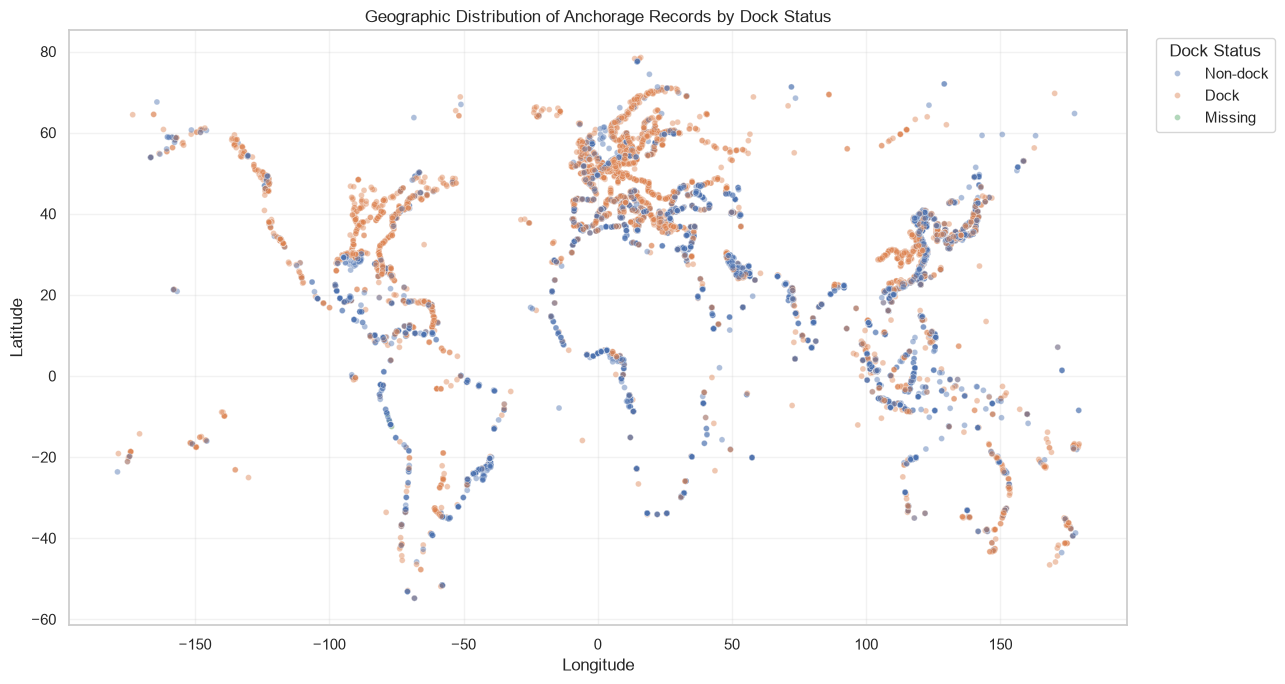

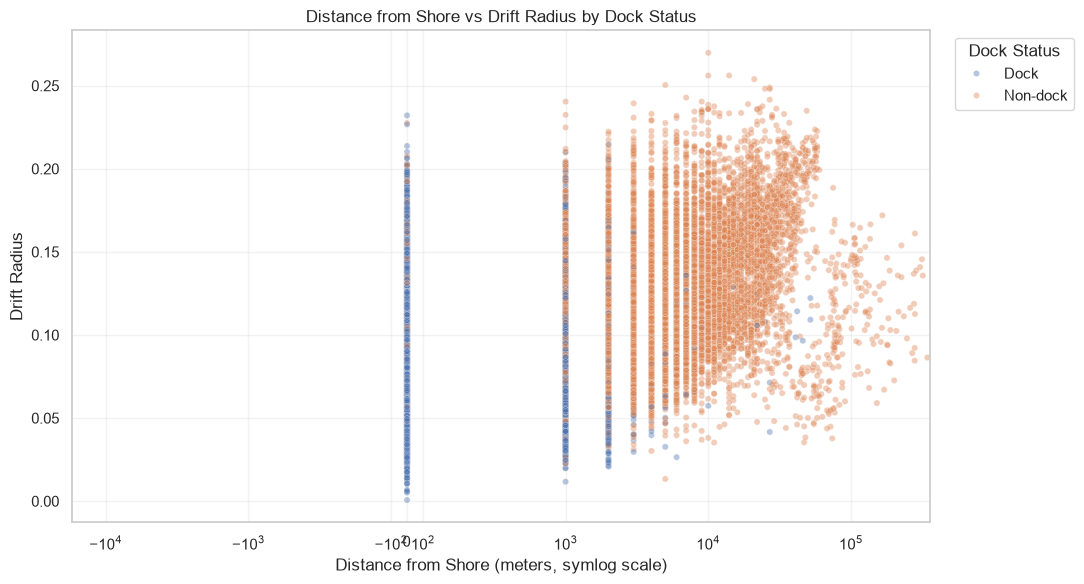

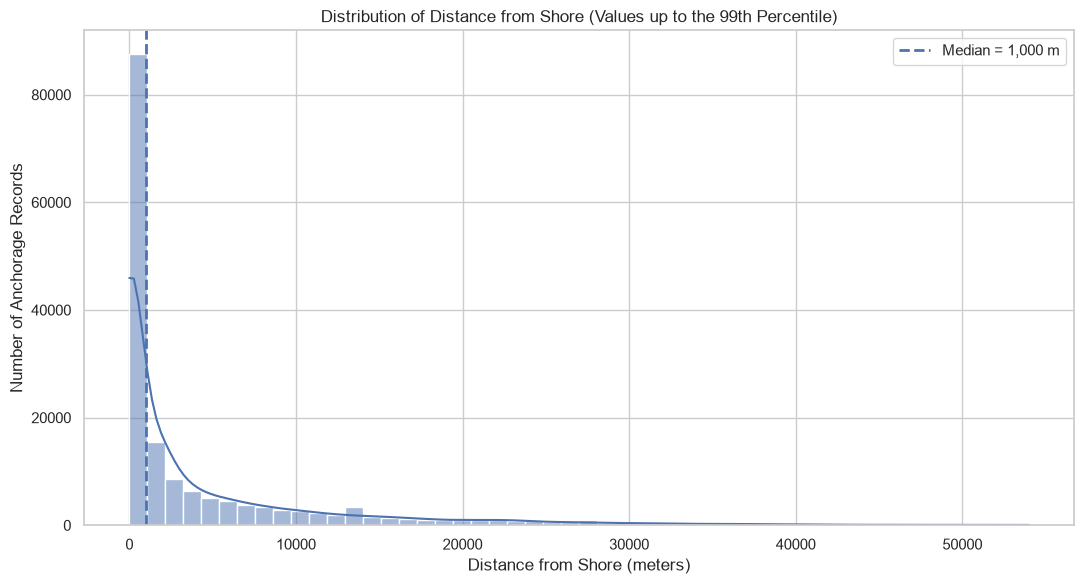

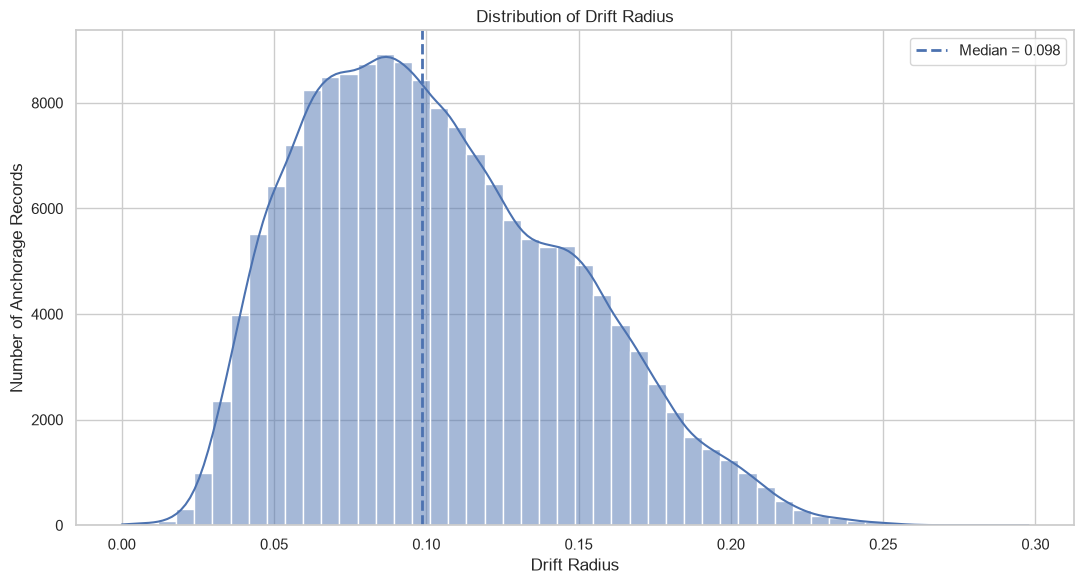

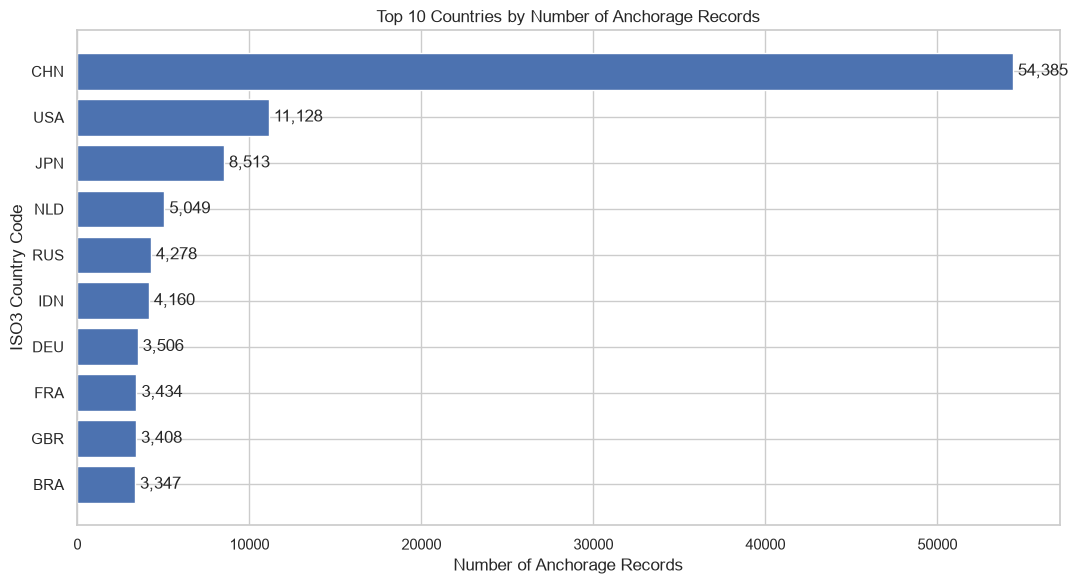

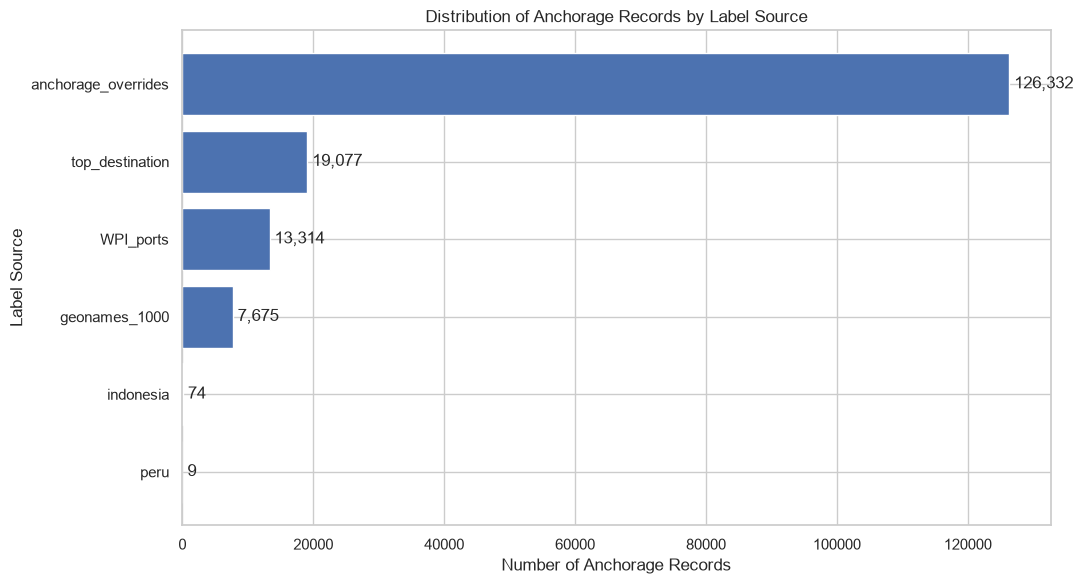

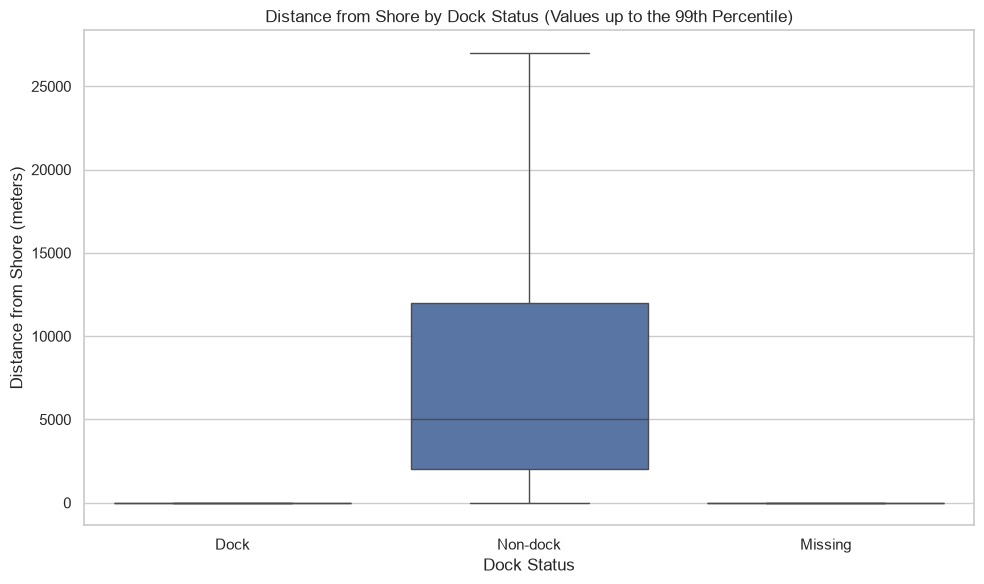

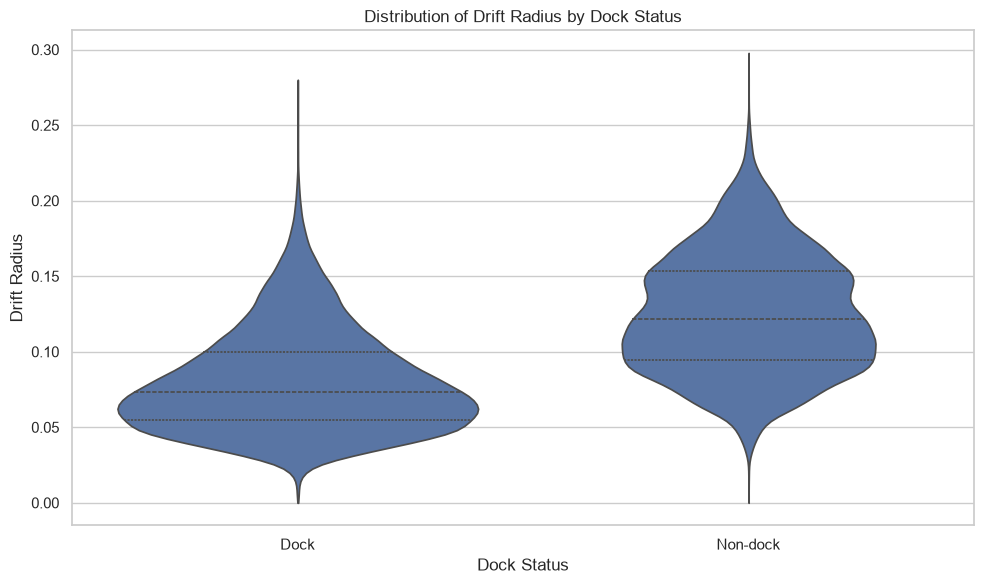

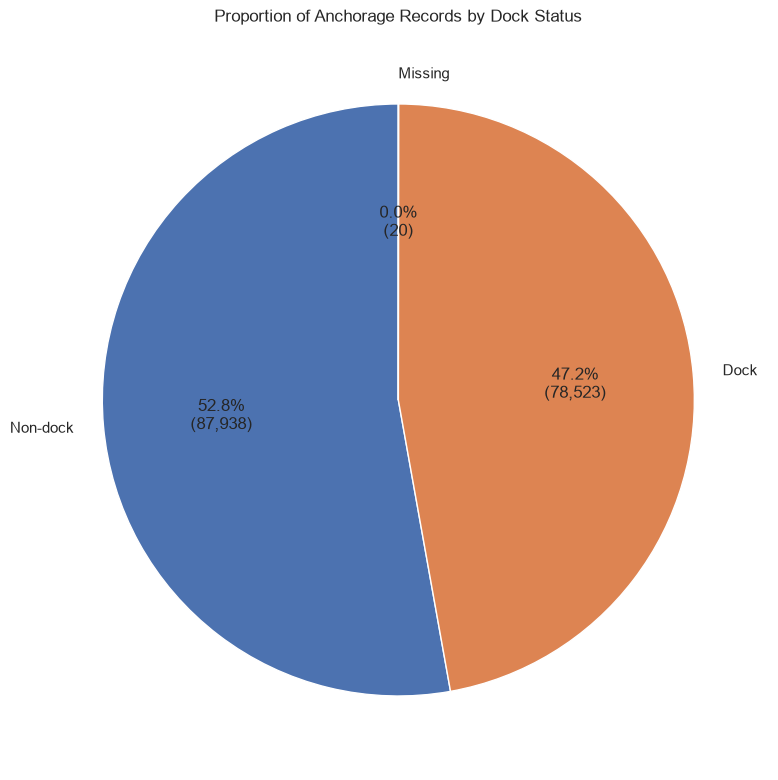

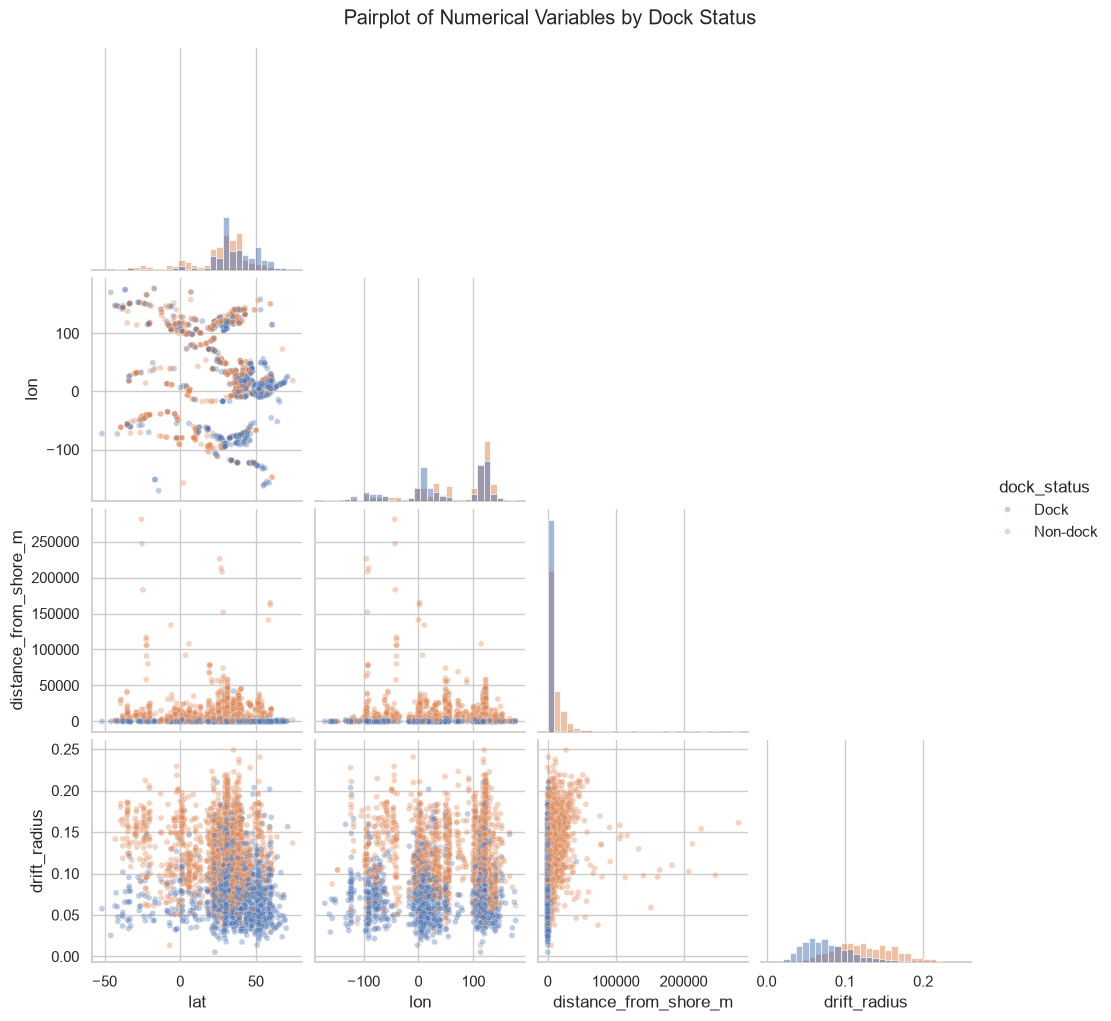

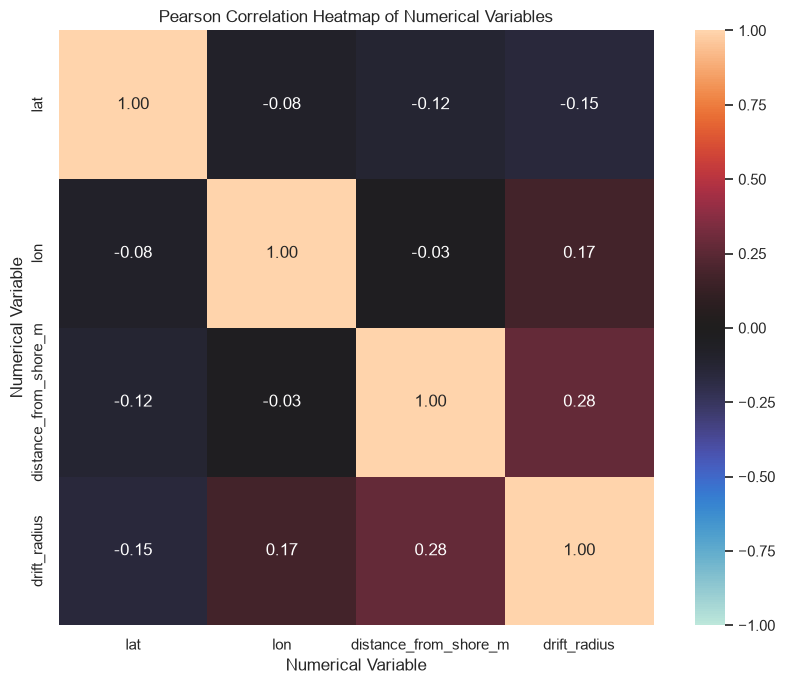

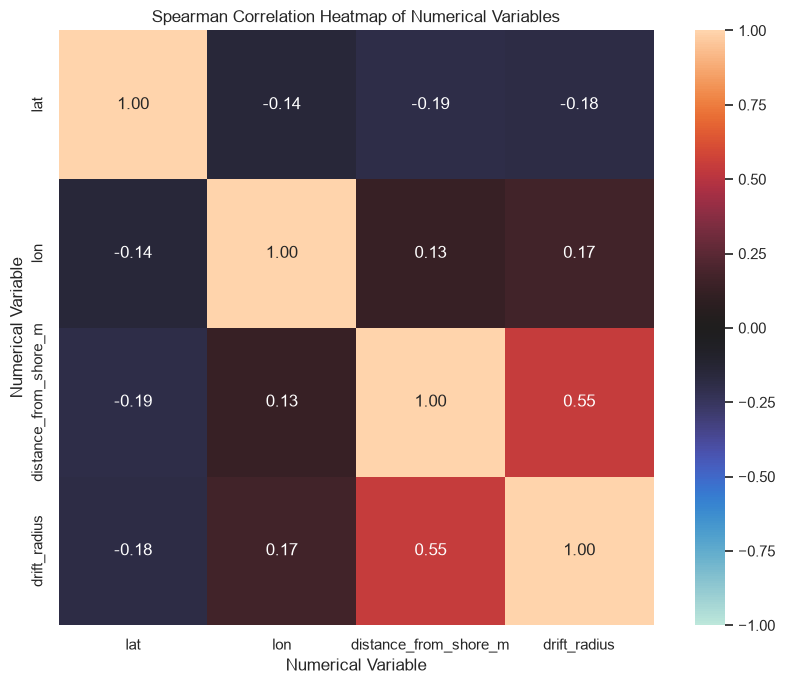

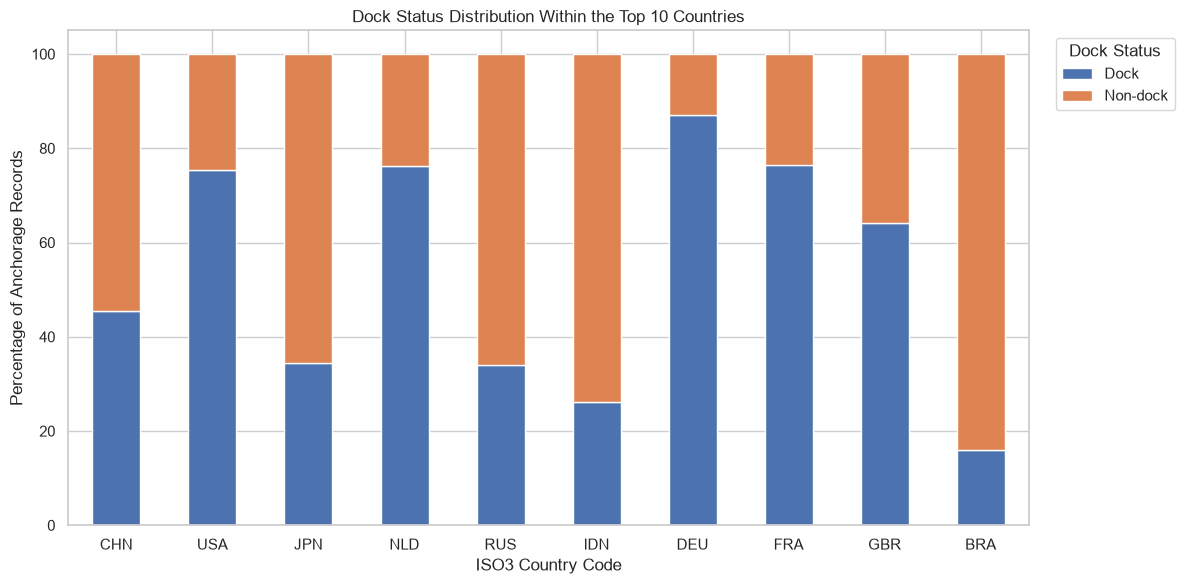

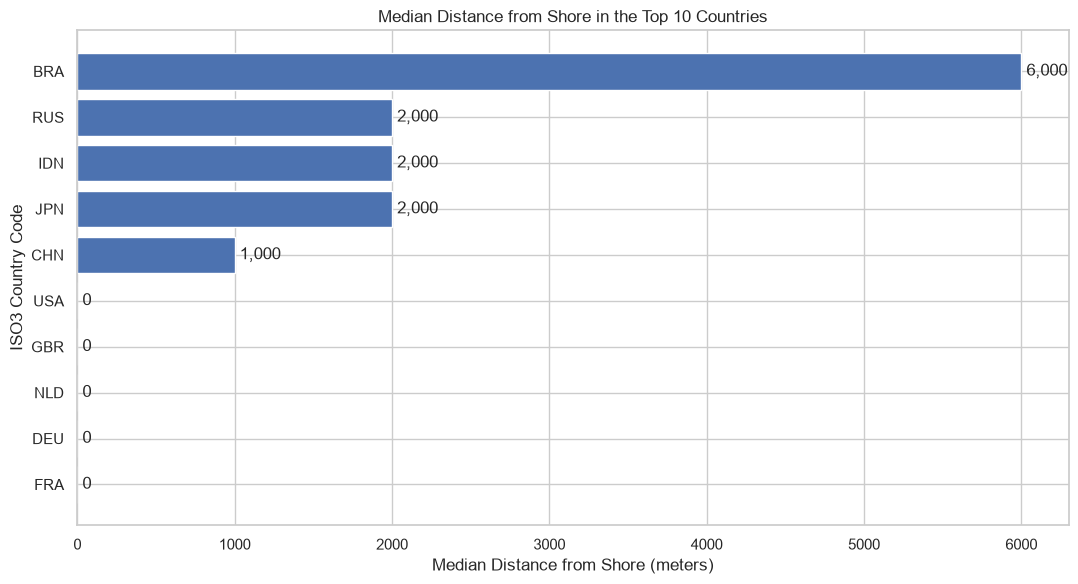

In [19]:
# ============================================================
# Section 6.3 - Informative Data Visualizations
# ============================================================

# ------------------------------------------------------------
# Prepare a clean visualization dataset
# ------------------------------------------------------------

visualization_data = ocean_data.copy()

# Remove invalid geographical coordinates for geographic plots.
visualization_data = visualization_data[
    visualization_data["lat"].between(-90, 90)
    & visualization_data["lon"].between(-180, 180)
].copy()

# Convert dock to a readable categorical variable.
visualization_data["dock_status"] = (
    visualization_data["dock"]
    .map({
        True: "Dock",
        False: "Non-dock"
    })
    .fillna("Missing")
)

# Replace missing source values with an explicit label.
visualization_data["label_source_clean"] = (
    visualization_data["label_source"]
    .fillna("Missing")
    .astype(str)
)

# Use reproducible samples for plots that would otherwise contain
# too many points and become slow or unreadable.
scatter_sample = visualization_data.sample(
    n=min(20000, len(visualization_data)),
    random_state=42
)

pairplot_sample = visualization_data[
    [
        "lat",
        "lon",
        "distance_from_shore_m",
        "drift_radius",
        "dock_status"
    ]
].dropna().sample(
    n=min(
        3000,
        len(
            visualization_data[
                [
                    "lat",
                    "lon",
                    "distance_from_shore_m",
                    "drift_radius",
                    "dock_status"
                ]
            ].dropna()
        )
    ),
    random_state=42
)

print("=" * 100)
print("SECTION 6.3 - INFORMATIVE DATA VISUALIZATIONS")
print("=" * 100)


# ============================================================
# 1. Scatterplot - Geographic distribution
# ============================================================

plt.figure(figsize=(13, 7))

sns.scatterplot(
    data=scatter_sample,
    x="lon",
    y="lat",
    hue="dock_status",
    alpha=0.45,
    s=18
)

plt.title("Geographic Distribution of Anchorage Records by Dock Status")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Dock Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# 2. Scatterplot - Distance from shore vs drift radius
# ============================================================

relationship_sample = visualization_data[
    [
        "distance_from_shore_m",
        "drift_radius",
        "dock_status"
    ]
].dropna().sample(
    n=min(
        20000,
        len(
            visualization_data[
                [
                    "distance_from_shore_m",
                    "drift_radius",
                    "dock_status"
                ]
            ].dropna()
        )
    ),
    random_state=42
)

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=relationship_sample,
    x="distance_from_shore_m",
    y="drift_radius",
    hue="dock_status",
    alpha=0.4,
    s=20
)

plt.xscale("symlog", linthresh=1000)

plt.title("Distance from Shore vs Drift Radius by Dock Status")
plt.xlabel("Distance from Shore (meters, symlog scale)")
plt.ylabel("Drift Radius")
plt.legend(
    title="Dock Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# 3. Histogram - Distance from shore
# ============================================================

distance_values = visualization_data[
    "distance_from_shore_m"
].dropna()

distance_upper_limit = distance_values.quantile(0.99)

plt.figure(figsize=(11, 6))

sns.histplot(
    distance_values[
        distance_values <= distance_upper_limit
    ],
    bins=50,
    kde=True
)

plt.axvline(
    distance_values.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {distance_values.median():,.0f} m"
)

plt.title(
    "Distribution of Distance from Shore "
    "(Values up to the 99th Percentile)"
)
plt.xlabel("Distance from Shore (meters)")
plt.ylabel("Number of Anchorage Records")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4. Histogram - Drift radius
# ============================================================

drift_values = visualization_data[
    "drift_radius"
].dropna()

plt.figure(figsize=(11, 6))

sns.histplot(
    drift_values,
    bins=50,
    kde=True
)

plt.axvline(
    drift_values.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {drift_values.median():.3f}"
)

plt.title("Distribution of Drift Radius")
plt.xlabel("Drift Radius")
plt.ylabel("Number of Anchorage Records")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 5. Bar chart - Top 10 countries
# ============================================================

top_countries = (
    visualization_data["iso3"]
    .fillna("Missing")
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries by Number of Anchorage Records")
plt.xlabel("Number of Anchorage Records")
plt.ylabel("ISO3 Country Code")

for index, value in enumerate(top_countries.values):
    plt.text(
        value,
        index,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6. Bar chart - Label source distribution
# ============================================================

source_counts = (
    visualization_data["label_source_clean"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))

plt.barh(
    source_counts.index,
    source_counts.values
)

plt.title("Distribution of Anchorage Records by Label Source")
plt.xlabel("Number of Anchorage Records")
plt.ylabel("Label Source")

for index, value in enumerate(source_counts.values):
    plt.text(
        value,
        index,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 7. Boxplot - Distance from shore by dock status
# ============================================================

boxplot_distance_data = visualization_data[
    visualization_data["distance_from_shore_m"].notna()
    & (
        visualization_data["distance_from_shore_m"]
        <= distance_upper_limit
    )
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=boxplot_distance_data,
    x="dock_status",
    y="distance_from_shore_m",
    showfliers=False
)

plt.title(
    "Distance from Shore by Dock Status "
    "(Values up to the 99th Percentile)"
)
plt.xlabel("Dock Status")
plt.ylabel("Distance from Shore (meters)")
plt.tight_layout()
plt.show()


# ============================================================
# 8. Violin plot - Drift radius by dock status
# ============================================================

violin_data = visualization_data[
    visualization_data["drift_radius"].notna()
].copy()

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=violin_data,
    x="dock_status",
    y="drift_radius",
    inner="quartile",
    cut=0
)

plt.title("Distribution of Drift Radius by Dock Status")
plt.xlabel("Dock Status")
plt.ylabel("Drift Radius")
plt.tight_layout()
plt.show()


# ============================================================
# 9. Pie chart - Dock status
# ============================================================

dock_counts = (
    visualization_data["dock_status"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    dock_counts.values,
    labels=dock_counts.index,
    autopct=lambda percentage: (
        f"{percentage:.1f}%\n"
        f"({int(round(percentage / 100 * dock_counts.sum())):,})"
    ),
    startangle=90
)

plt.title("Proportion of Anchorage Records by Dock Status")
plt.tight_layout()
plt.show()


# ============================================================
# 10. Pairplot - Numerical variables
# ============================================================

pairplot_figure = sns.pairplot(
    pairplot_sample,
    vars=[
        "lat",
        "lon",
        "distance_from_shore_m",
        "drift_radius"
    ],
    hue="dock_status",
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.35,
        "s": 18
    },
    diag_kws={
        "bins": 30
    }
)

pairplot_figure.fig.suptitle(
    "Pairplot of Numerical Variables by Dock Status",
    y=1.02
)

plt.show()


# ============================================================
# 11. Pearson correlation heatmap
# ============================================================

numerical_visualization_columns = [
    "lat",
    "lon",
    "distance_from_shore_m",
    "drift_radius"
]

pearson_correlation = (
    visualization_data[numerical_visualization_columns]
    .corr(method="pearson")
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Pearson Correlation Heatmap of Numerical Variables")
plt.xlabel("Numerical Variable")
plt.ylabel("Numerical Variable")
plt.tight_layout()
plt.show()


# ============================================================
# 12. Spearman correlation heatmap
# ============================================================

spearman_correlation = (
    visualization_data[numerical_visualization_columns]
    .corr(method="spearman")
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Spearman Correlation Heatmap of Numerical Variables")
plt.xlabel("Numerical Variable")
plt.ylabel("Numerical Variable")
plt.tight_layout()
plt.show()


# ============================================================
# 13. Additional plot - Dock percentage by top countries
# ============================================================

top_country_codes = (
    visualization_data["iso3"]
    .value_counts()
    .head(10)
    .index
)

country_dock_distribution = pd.crosstab(
    visualization_data.loc[
        visualization_data["iso3"].isin(top_country_codes),
        "iso3"
    ],
    visualization_data.loc[
        visualization_data["iso3"].isin(top_country_codes),
        "dock_status"
    ],
    normalize="index"
) * 100

country_dock_distribution = (
    country_dock_distribution
    .reindex(top_country_codes)
)

country_dock_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Dock Status Distribution Within the Top 10 Countries")
plt.xlabel("ISO3 Country Code")
plt.ylabel("Percentage of Anchorage Records")
plt.xticks(rotation=0)
plt.legend(
    title="Dock Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


# ============================================================
# 14. Additional plot - Median distance from shore by country
# ============================================================

median_distance_by_country = (
    visualization_data[
        visualization_data["iso3"].isin(top_country_codes)
    ]
    .groupby("iso3")["distance_from_shore_m"]
    .median()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))

plt.barh(
    median_distance_by_country.index,
    median_distance_by_country.values
)

plt.title(
    "Median Distance from Shore in the Top 10 Countries"
)
plt.xlabel("Median Distance from Shore (meters)")
plt.ylabel("ISO3 Country Code")

for index, value in enumerate(
    median_distance_by_country.values
):
    plt.text(
        value,
        index,
        f" {value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Section 7 - Index Analysis
# ============================================================

print("=" * 100)
print("SECTION 7 - INDEX ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------
# Basic index information
# ------------------------------------------------------------

print("\nIndex Type:")
print(type(ocean_data.index))

print("\nIndex Name:")
print(ocean_data.index.name)

print("\nIndex Data Type:")
print(ocean_data.index.dtype)

print("\nIndex Length:")
print(len(ocean_data.index))

# ------------------------------------------------------------
# Is the index unique?
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("INDEX UNIQUENESS")
print("=" * 100)

print(f"Is index unique? {ocean_data.index.is_unique}")

# ------------------------------------------------------------
# Is the index sorted?
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("INDEX SORTING")
print("=" * 100)

print(f"Is index monotonic increasing? {ocean_data.index.is_monotonic_increasing}")
print(f"Is index monotonic decreasing? {ocean_data.index.is_monotonic_decreasing}")

# ------------------------------------------------------------
# Is the index time-based?
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TIME-BASED INDEX")
print("=" * 100)

is_datetime = pd.api.types.is_datetime64_any_dtype(ocean_data.index)

print(f"Datetime index: {is_datetime}")

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\nFirst 10 index values:")

display(ocean_data.index[:10])

print("\nLast 10 index values:")

display(ocean_data.index[-10:])

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Property":[
        "Index Type",
        "Unique",
        "Sorted Increasing",
        "Sorted Decreasing",
        "Time Based",
        "Number of Records"
    ],

    "Value":[
        type(ocean_data.index).__name__,
        ocean_data.index.is_unique,
        ocean_data.index.is_monotonic_increasing,
        ocean_data.index.is_monotonic_decreasing,
        is_datetime,
        len(ocean_data.index)
    ]

})

print("\n" + "=" * 100)
print("INDEX SUMMARY")
print("=" * 100)

display(summary)

SECTION 7 - INDEX ANALYSIS

Index Type:
<class 'pandas.RangeIndex'>

Index Name:
None

Index Data Type:
int64

Index Length:
166482

INDEX UNIQUENESS
Is index unique? True

INDEX SORTING
Is index monotonic increasing? True
Is index monotonic decreasing? False

TIME-BASED INDEX
Datetime index: False

First 10 index values:


RangeIndex(start=0, stop=10, step=1)


Last 10 index values:


RangeIndex(start=166472, stop=166482, step=1)


INDEX SUMMARY


,Property,Value
0,Index Type,RangeIndex
1,Unique,True
2,Sorted Increasing,True
3,Sorted Decreasing,False
4,Time Based,False
5,Number of Records,166482


## Discussion – Section 7

The dataset uses a standard **RangeIndex**, which assigns a unique sequential integer to every observation.

The index is **unique**, meaning that each row can be identified without ambiguity.

The index is **not time-based**, since it does not contain dates or timestamps. Therefore, no temporal analysis can be performed using the index itself, and changes over time cannot be investigated.

The index is **sorted in ascending order**, reflecting the original loading order of the dataset.

Overall, the index serves only as a row identifier and does not contain meaningful analytical information. All analyses performed in previous sections are therefore independent of the index and are based solely on the dataset variables.

# 8. Data Insights and Overall Conclusions

## Overall Summary

This exploratory data analysis examined a global dataset of maritime anchorages. The analysis included data quality assessment, descriptive statistics, categorical and numerical variable analysis, correlation analysis, relationship analysis, visualization, and index evaluation. Overall, the dataset is large, well-structured, and suitable for exploratory analysis, although several limitations and data quality issues should be considered.

---

## Main Insight 1 – Strong Geographical Influence

One of the strongest findings is the clear relationship between geographical location and country. Latitude and longitude show a strong association with the ISO3 country code (Cramér's V values of approximately 0.75–0.81). This result is expected because geographical coordinates naturally determine the country in which an anchorage is located.

---

## Main Insight 2 – Dock Status is Related to Operational Characteristics

The analysis revealed relatively strong relationships between the dock indicator and both the distance from shore and the drift radius. Dock locations generally appear closer to the shoreline and exhibit different drift characteristics compared to non-dock anchorages. This suggests that operational behavior differs between coastal and offshore anchorage areas.

---

## Main Insight 3 – Most Variables are Weakly Correlated

Although the dataset contains many variables, most numerical variables exhibit only weak linear relationships. The strongest numerical relationship was observed between distance from shore and drift radius, while most other variable pairs showed only limited dependence. This indicates that each variable contributes different information and should not be considered redundant.

---

## Potential Bias and Data Risks

The dataset is not evenly distributed across countries. A relatively small number of countries contribute a large proportion of the observations, while many countries are represented by only a few records. Consequently, analyses performed on the complete dataset may be biased toward regions with greater data availability.

In addition, a small number of missing values and at least one clearly invalid geographical coordinate were identified. Although these issues affect only a tiny portion of the dataset, they demonstrate that data quality validation remains essential before applying analytical or predictive models.

---

## Possible Limitations for Engineering and Statistical Applications

Several considerations should be taken into account before using this dataset for engineering or statistical purposes:

- The dataset does not include any temporal information, making time-series analysis impossible.
- Geographic coverage is uneven across countries, which may reduce the generalizability of statistical models.
- Strong class imbalance exists for several categorical variables.
- A small number of erroneous records may influence algorithms that are sensitive to outliers.
- Correlation does not imply causation; therefore, statistical associations should not be interpreted as causal relationships.

---

## What I Learned from the Analysis

This analysis demonstrated that understanding the data is as important as applying statistical methods. Many relationships that initially appeared likely turned out to be weak, while others became much clearer after visualization and categorical analysis.

The work also highlighted the importance of validating data quality before drawing conclusions. Even very large datasets may contain missing values, invalid records, or biased distributions that can influence analytical results.

Overall, this project improved my understanding of exploratory data analysis and demonstrated how statistical techniques and visualizations complement each other to provide a more comprehensive understanding of real-world datasets.

# 9. Bonus

## 9.1 Time Dependency

The dataset does not contain any temporal variable such as a date, timestamp, month, or year. Therefore, it is not possible to investigate trends over time, seasonality, or changes in anchorage behavior across different periods.

If temporal information were available, several interesting analyses could be performed, including:

- Seasonal changes in anchorage activity.
- Long-term trends in maritime traffic.
- Changes before and after major global events.
- Weekly or monthly anchorage utilization patterns.

Therefore, no conclusions regarding time dependency can be drawn from the current dataset.

---

## 9.2 Feature Engineering

Several additional features could improve future analyses and predictive models:

- Distance category (Near Shore, Coastal, Offshore).
- Hemisphere (Northern or Southern).
- Geographic region derived from latitude and longitude.
- Anchorage density within a geographical radius.
- Country-level aggregation features.
- Drift radius classification (Low, Medium, High).
- Regional risk indicators based on historical maritime activity.

These engineered features could improve clustering, classification, and anomaly detection tasks.

---

## 9.3 Hypothesis Testing

Several statistical hypotheses could be investigated using this dataset.

### Hypothesis 1

**H0:** Dock and non-dock anchorages have the same average distance from shore.

**H1:** Dock and non-dock anchorages have different average distances from shore.

A two-sample t-test or a non-parametric Mann–Whitney U test could be applied after checking the required assumptions.

### Hypothesis 2

**H0:** Drift radius is independent of dock status.

**H1:** Drift radius differs between dock and non-dock anchorages.

This hypothesis could also be tested using parametric or non-parametric statistical methods.

### Hypothesis 3

**H0:** The distribution of anchorage records across countries is uniform.

**H1:** The distribution differs significantly across countries.

A Chi-Square Goodness-of-Fit test could be used to evaluate this hypothesis.

---

## 9.4 Suggestions for Future Research

Several directions could extend this study:

- Integrate temporal information to study long-term maritime activity.
- Combine the dataset with weather, tides, and ocean current data.
- Investigate relationships between anchorage locations and commercial shipping routes.
- Develop machine learning models for anchorage classification or anomaly detection.
- Perform spatial clustering using latitude and longitude.
- Compare anchorage behavior across different geographical regions.

Overall, integrating additional external data sources would considerably increase the analytical value of the dataset and enable more advanced predictive and operational studies.